# **1. Switch Runtime to CPU and Install CPU Packages**

At this stage, use a **CPU runtime** because the following steps only require lightweight packages for search, downloading files, XML parsing, section selection, and keyword search.

To switch to CPU in Google Colab:

1. Go to **Runtime** in the top menu.
2. Click **Change runtime type**.
3. Under **Hardware accelerator**, select **CPU** or **None**.
4. Click **Save**.

Deep-learning packages will be installed later, after switching to a **GPU runtime**.

In [ ]:
!pip -q install pandas requests tqdm openpyxl ipywidgets numpy

# **2. Load Interface Helpers**


In [ ]:
import csv
import io
import json
import os
import re
import shutil
import time
import xml.etree.ElementTree as ET
from collections import Counter, defaultdict
from dataclasses import dataclass, field
from getpass import getpass
from pathlib import Path
from typing import Any
import numpy as np
import pandas as pd
import requests
from IPython.display import HTML, display
from tqdm.auto import tqdm

try:
    import ipywidgets as widgets
except Exception:
    widgets = None


STYLE = """
<style>
.screen-card {
  border: 1px solid #d9e2ec;
  border-left: 6px solid #2563eb;
  border-radius: 10px;
  padding: 16px 18px;
  margin: 12px 0;
  background: #fbfdff;
  box-shadow: 0 1px 3px rgba(15, 23, 42, 0.08);
}
.screen-card h3 {
  margin: 0 0 6px 0;
  color: #0f172a;
  font-size: 18px;
}
.screen-card p {
  margin: 4px 0;
  color: #334155;
  line-height: 1.45;
}
.metric-grid {
  display: grid;
  grid-template-columns: repeat(auto-fit, minmax(170px, 1fr));
  gap: 10px;
  margin: 12px 0;
}
.metric-card {
  border: 1px solid #e2e8f0;
  border-radius: 10px;
  padding: 12px;
  background: white;
}
.metric-value {
  font-size: 24px;
  font-weight: 700;
  color: #0f172a;
}
.metric-label {
  font-size: 12px;
  color: #64748b;
  text-transform: uppercase;
  letter-spacing: .04em;
}
.soft-note {
  border-radius: 8px;
  padding: 10px 12px;
  background: #f8fafc;
  border: 1px solid #e2e8f0;
  color: #334155;
}
</style>
"""
display(HTML(STYLE))


def card(title, body="", accent="#2563eb"):
    display(HTML(f"""
    <div class="screen-card" style="border-left-color:{accent}">
      <h3>{title}</h3>
      <p>{body}</p>
    </div>
    """))


def warning_card(title, body):
    card(title, body, accent="#d97706")


def success_card(title, body):
    card(title, body, accent="#16a34a")


def metric_cards(metrics):
    html = ['<div class="metric-grid">']
    for label, value in metrics:
        html.append(f'<div class="metric-card"><div class="metric-value">{value}</div><div class="metric-label">{label}</div></div>')
    html.append("</div>")
    display(HTML("".join(html)))


def display_counts(label, df, pmc_col="pmc_id"):
    metrics = [("Rows", f"{len(df):,}")]
    if pmc_col in df.columns:
        metrics.append(("Unique PMC IDs", f"{df[pmc_col].dropna().astype(str).nunique():,}"))
    card(label, "Preview of the current dataset.")
    metric_cards(metrics)
    display(df.head())


def chunks(values, size):
    values = list(values)
    for start in range(0, len(values), size):
        yield values[start:start + size]


def normalize_bool(value):
    return str(value or "").strip().lower() in {"true", "yes", "y", "1", "relevant"}


def clean_text_for_csv(value):
    return str(value or "").replace("\r", " ").replace("\n", " ").strip()


# **3. Project Folder Settings**

In this step, you choose the main folder where all files from this workflow will be saved.

You can change the value of `project_folder_name` if you want to use a different project name.

The code will automatically create three folders inside your project folder:

- `downloaded_articles`: stores the downloaded XML files from open-access articles.
- `output`: stores generated results, tables, logs, and exported files.
- `src`: stores helper scripts or reusable code used in later steps.

By default, everything will be saved under `/content/open_access_screening/` in Colab. This means the files are temporary and may be deleted when the Colab session ends unless you download them or save them to Google Drive later.

In [ ]:
# @title Project folder settings
project_folder_name = "open_access_screening"  # @param {type:"string"}

PROJECT_ROOT = Path("/content") / project_folder_name
XML_DIR = PROJECT_ROOT / "downloaded_articles"
OUTPUT_DIR = PROJECT_ROOT / "output"
SRC_DIR = PROJECT_ROOT / "src"

for folder in [XML_DIR, OUTPUT_DIR, SRC_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

success_card(
    "Project folders are ready",
    f"Files will be saved under {PROJECT_ROOT}."
)
metric_cards([
    ("Project root", str(PROJECT_ROOT)),
    ("XML folder", str(XML_DIR)),
    ("Output folder", str(OUTPUT_DIR)),
])


# **4. Open PubMed Central (PMC) and Provide Search Input**

This step helps you connect your notebook workflow with the real **PubMed Central (PMC)** search interface.

The code first displays a button that opens the PMC website in a new browser tab. You can use the PMC website to search for articles, apply filters, check whether the results are relevant, and refine your search strategy before bringing the search input back into the notebook.

After that, the code provides three input options:

- **Paste PMC query**: use this if you want to paste a normal text search query, such as keywords, MeSH terms, or Boolean search terms.
- **Paste PMC URL**: use this if you already searched and filtered articles on the PMC website and want to paste the full search-results URL.
- **Paste PMCIDs/PMIDs**: use this if you already have a list of article identifiers and want the notebook to work directly with those articles.

After choosing the input type, paste your query, URL, or article IDs into the text box and click **Submit search input**. The notebook will save your selected input mode and pasted text, so the next cell can prepare it for searching or downloading articles.

If you have already started searching for papers in PMC but do not yet have a final list of articles, we suggest using the **PMC URL** option after applying your filters on the PMC website.

**To use the URL option, you need to copy and paste the URL into the box after running the following cell, as shown in the example.**

In [ ]:
card(
    "Use the real PMC search interface",
    "Open PMC, search and filter there, then paste the query, URL, or IDs below."
)

display(HTML("""
<p>
  <a href="https://pmc.ncbi.nlm.nih.gov/" target="_blank"
     style="display:inline-block;background:#2563eb;color:white;padding:10px 14px;
            border-radius:8px;text-decoration:none;font-weight:600;">
    Open PMC Search
  </a>
</p>
<div class="soft-note">
  Recommended: search and filter in PMC first. Then copy either the search text,
  the full https://... URL, or a PMCID/PMID list back into this notebook.
</div>
"""))

if widgets is None:
    warning_card("Widget support is unavailable", "The next cell will ask for your query, URL, or IDs using text prompts.")
    pmc_input_mode_widget = None
else:
    PMC_INPUT_SUBMITTED = False
    PMC_INPUT_MODE_SUBMITTED = ""
    PMC_PASTED_TEXT_SUBMITTED = ""

    pmc_input_mode_widget = widgets.ToggleButtons(
        options=[
            ("Paste PMC query", "query"),
            ("Paste PMC URL", "url"),
            ("Paste PMCIDs/PMIDs", "ids"),
        ],
        value="query",
        description="Input:",
    )
    pmc_query_or_url_widget = widgets.Textarea(
        value="",
        placeholder=(
            "Paste one PMC query, one PMC search URL, or a list of PMCIDs/PMIDs.\n"
            "Examples:\n"
            "antibiotic resistance AND Escherichia coli\n"
            "https://pmc.ncbi.nlm.nih.gov/?term=antibiotic+resistance\n"
            "PMC1234567\nPMC7654321"
        ),
        description="Paste:",
        layout=widgets.Layout(width="95%", height="170px"),
    )
    pmc_submit_button = widgets.Button(
        description="Submit search input",
        button_style="success",
        tooltip="Save this query, URL, or ID list for the next cell.",
        layout=widgets.Layout(width="220px"),
    )
    pmc_submit_output = widgets.Output()

    def submit_pmc_input(_):
        global PMC_INPUT_SUBMITTED, PMC_INPUT_MODE_SUBMITTED, PMC_PASTED_TEXT_SUBMITTED
        with pmc_submit_output:
            pmc_submit_output.clear_output()
            text = pmc_query_or_url_widget.value.strip()
            if not text:
                warning_card("Nothing submitted", "Paste a query, URL, or ID list before clicking Submit.")
                return
            PMC_INPUT_SUBMITTED = True
            PMC_INPUT_MODE_SUBMITTED = pmc_input_mode_widget.value
            PMC_PASTED_TEXT_SUBMITTED = text
            success_card(
                "Search input submitted",
                f"Saved input mode: {PMC_INPUT_MODE_SUBMITTED}. Run the next cell to prepare it for searching or download."
            )

    pmc_submit_button.on_click(submit_pmc_input)

    display(widgets.VBox([
        pmc_input_mode_widget,
        pmc_query_or_url_widget,
        pmc_submit_button,
        pmc_submit_output,
    ]))


In [ ]:
from urllib.parse import parse_qs, unquote_plus, urlparse


def extract_query_from_pmc_url(url_text):
    parsed = urlparse(str(url_text).strip())
    params = parse_qs(parsed.query)
    for key in ["term", "query", "q", "search", "kw"]:
        values = params.get(key)
        if values and str(values[0]).strip():
            return unquote_plus(str(values[0]).strip())
    raise ValueError(
        "Could not find a search query in the pasted URL. "
        "Please paste the query text instead, or paste PMCIDs/PMIDs."
    )


def parse_pmc_or_pubmed_ids(text):
    text = str(text or "")
    pmc_matches = re.findall(r"\bPMC\d+\b", text, flags=re.IGNORECASE)
    pmid_matches = re.findall(r"(?<!PMC)\b\d{5,10}\b", text, flags=re.IGNORECASE)

    pmcids = ["PMC" + re.sub(r"\D", "", value) for value in pmc_matches]
    pmids = [value for value in pmid_matches if value not in {re.sub(r"\D", "", pmc) for pmc in pmcids}]

    pmcids = list(dict.fromkeys(pmcids))
    pmids = list(dict.fromkeys(pmids))
    if not pmcids and not pmids:
        raise ValueError("No PMCIDs or PMIDs were found in the pasted text.")
    return pmcids, pmids


if widgets is not None and pmc_input_mode_widget is not None:
    if not globals().get("PMC_INPUT_SUBMITTED", False):
        raise ValueError("Click 'Submit search input' in the previous cell before running this cell.")
    PMC_INPUT_MODE = PMC_INPUT_MODE_SUBMITTED
    PMC_PASTED_TEXT = PMC_PASTED_TEXT_SUBMITTED
else:
    print("What are you pasting?")
    print("1. PMC query text")
    print("2. PMC search URL")
    print("3. PMCIDs/PMIDs")
    choice = input("Enter 1, 2, or 3: ").strip()
    PMC_INPUT_MODE = {"1": "query", "2": "url", "3": "ids"}.get(choice)
    if PMC_INPUT_MODE is None:
        raise ValueError("Please enter 1, 2, or 3.")
    print("Paste the text below. For multiple IDs, paste all IDs on one line or multiple lines.")
    PMC_PASTED_TEXT = input("Paste here: ").strip()

if not PMC_PASTED_TEXT:
    raise ValueError("Please paste a query, URL, or ID list.")

FINAL_PMC_QUERY = ""
PROVIDED_PMCIDS = []
PROVIDED_PMIDS = []

if PMC_INPUT_MODE == "query":
    FINAL_PMC_QUERY = PMC_PASTED_TEXT
elif PMC_INPUT_MODE == "url":
    FINAL_PMC_QUERY = extract_query_from_pmc_url(PMC_PASTED_TEXT)
elif PMC_INPUT_MODE == "ids":
    PROVIDED_PMCIDS, PROVIDED_PMIDS = parse_pmc_or_pubmed_ids(PMC_PASTED_TEXT)
else:
    raise ValueError(f"Unknown input mode: {PMC_INPUT_MODE}")

if PMC_INPUT_MODE == "ids":
    query_config_df = pd.DataFrame([{
        "input_mode": PMC_INPUT_MODE,
        "provided_pmcid_count": len(PROVIDED_PMCIDS),
        "provided_pmid_count": len(PROVIDED_PMIDS),
        "pasted_text_preview": PMC_PASTED_TEXT[:500],
    }])
else:
    query_config_df = pd.DataFrame([{
        "input_mode": PMC_INPUT_MODE,
        "final_pmc_query": FINAL_PMC_QUERY,
        "pasted_text_preview": PMC_PASTED_TEXT[:500],
    }])
query_config_df.to_csv(OUTPUT_DIR / "pmc_search_input_config.csv", index=False, encoding="utf-8-sig")

if PMC_INPUT_MODE == "ids":
    success_card("ID list is ready", "The next step will skip PMC search and download BioC XML for these IDs.")
else:
    success_card("PMC query is ready", "The search/count step will use exactly this one query.")
display(query_config_df)


# **5. NCBI Settings**

This step saves the settings needed to communicate with NCBI services during article search and download.

The notebook asks for your **email address** because NCBI recommends identifying the user or tool making requests. This helps NCBI contact you if there is a problem with automated requests.

You can also choose whether to provide an **NCBI API key**, which is provided by NCBI for free.

An NCBI API key is optional, but recommended. If you provide one, the notebook can use a shorter delay between requests. In this workflow, using an API key reduces the request delay from `0.35` seconds to `0.12` seconds, which can make downloading approximately **3 times faster**.

To get an NCBI API key:

1. Sign in to your **My NCBI** account.
2. Open your **NCBI Account Settings**.
3. Scroll to the **API Key Management** section.
4. Click **Create API Key**.
5. Copy the generated key and paste it when this notebook asks for it.

If you do not have a My NCBI account, you need to create one first. NCBI describes this process in its API key documentation.

If you have an API key, keep `has_ncbi_api_key` checked and paste the key when prompted.

If you do not have an API key, or you do not want to use one, leave `has_ncbi_api_key` unchecked. The notebook will still work, but it will use a more conservative request delay and may download articles more slowly.

In [ ]:
# @title NCBI settings
NCBI_TOOL = "open_access_screening_colab"
NCBI_EMAIL = ""  # @param {type:"string"}
has_ncbi_api_key = False  # @param {type:"boolean"}

if not NCBI_EMAIL or "@" not in NCBI_EMAIL:
    raise ValueError("Please enter your email address in the form field above, then rerun this cell.")

if has_ncbi_api_key:
    NCBI_API_KEY = getpass("Paste your NCBI API key: ").strip()
else:
    NCBI_API_KEY = ""

NCBI_DELAY_SECONDS = 0.12 if NCBI_API_KEY else 0.35

success_card(
    "NCBI settings saved",
    "The notebook will use a conservative request delay based on whether an API key was provided."
)
metric_cards([
    ("Email", NCBI_EMAIL),
    ("API key provided", bool(NCBI_API_KEY)),
    ("Delay seconds", NCBI_DELAY_SECONDS),
])


# **6. Count Results, Then Download BioC XML**

In [ ]:
EUTILS_ESEARCH = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/esearch.fcgi"
PMC_IDCONV = "https://pmc.ncbi.nlm.nih.gov/tools/idconv/api/v1/articles/"
BIOC_PMC_BASE = "https://www.ncbi.nlm.nih.gov/research/bionlp/RESTful/pmcoa.cgi/BioC_xml"


def ncbi_get(url, params=None, timeout=60):
    params = dict(params or {})
    if NCBI_API_KEY:
        params["api_key"] = NCBI_API_KEY
    response = requests.get(url, params=params, timeout=timeout)
    response.raise_for_status()
    time.sleep(NCBI_DELAY_SECONDS)
    return response


def search_pmc_count(query):
    params = {
        "db": "pmc",
        "term": query,
        "retmode": "json",
        "retmax": 0,
        "tool": NCBI_TOOL,
        "email": NCBI_EMAIL,
    }
    payload = ncbi_get(EUTILS_ESEARCH, params=params).json()
    result = payload.get("esearchresult", {})
    return int(result.get("count", 0)), result.get("querytranslation", "")


def fetch_pmc_ids(query, max_records=None, batch_size=10000):
    total_count, query_translation = search_pmc_count(query)
    records_to_fetch = total_count if max_records is None else min(total_count, int(max_records))

    rows = []
    for retstart in tqdm(range(0, records_to_fetch, batch_size), desc="Fetching PMC IDs"):
        retmax = min(batch_size, records_to_fetch - retstart)
        params = {
            "db": "pmc",
            "term": query,
            "retmode": "json",
            "retstart": retstart,
            "retmax": retmax,
            "sort": "relevance",
            "tool": NCBI_TOOL,
            "email": NCBI_EMAIL,
        }
        payload = ncbi_get(EUTILS_ESEARCH, params=params).json()
        ids = payload.get("esearchresult", {}).get("idlist", [])

        for local_rank, pmc_numeric_id in enumerate(ids, start=retstart + 1):
            pmcid = str(pmc_numeric_id)
            if not pmcid.upper().startswith("PMC"):
                pmcid = "PMC" + pmcid

            rows.append({
                "pmcid": pmcid
            })

    return rows


def convert_pmids_to_pmcids(pmids):
    records = []

    for batch in tqdm(list(chunks(pmids, 200)), desc="Converting PMIDs to PMCIDs"):
        params = {
            "ids": ",".join(batch),
            "format": "json",
            "tool": NCBI_TOOL,
            "email": NCBI_EMAIL,
        }
        payload = ncbi_get(PMC_IDCONV, params=params).json()
        records.extend(payload.get("records", []))

    conversion_df = pd.DataFrame(records)
    conversion_df.to_csv(
        OUTPUT_DIR / "provided_pmid_to_pmcid_conversion.csv",
        index=False,
        encoding="utf-8-sig"
    )

    if conversion_df.empty or "pmcid" not in conversion_df.columns:
        return []

    return conversion_df["pmcid"].dropna().astype(str).tolist()


def valid_bioc_xml(text):
    sample = (text or "")[:1000].lower()
    return "<collection" in sample or "<document" in sample


def download_bioc_xml_for_pmcids(pmcids, xml_dir=XML_DIR):
    xml_dir.mkdir(parents=True, exist_ok=True)

    rows = []

    for pmcid in tqdm(sorted(set(map(str, pmcids))), desc="Downloading BioC XML"):
        clean_pmcid = pmcid if pmcid.upper().startswith("PMC") else f"PMC{pmcid}"
        url = f"{BIOC_PMC_BASE}/{clean_pmcid}/unicode"
        output_file = xml_dir / f"{clean_pmcid}.xml"

        status = "downloaded"
        error = ""

        try:
            response = requests.get(url, timeout=90)

            if response.status_code != 200:
                status = f"http_{response.status_code}"

            elif not valid_bioc_xml(response.text):
                status = "not_available_as_open_access_bioc"

            else:
                output_file.write_text(response.text, encoding="utf-8")

        except Exception as exc:
            status = "error"
            error = f"{type(exc).__name__}: {exc}"

        rows.append({
            "pmcid": clean_pmcid,
            "status": status,
            "xml_file": str(output_file) if output_file.exists() else "",
            "error": error,
        })

        time.sleep(NCBI_DELAY_SECONDS)

    df = pd.DataFrame(rows)
    df.to_csv(
        OUTPUT_DIR / "bioc_download_status.csv",
        index=False,
        encoding="utf-8-sig"
    )

    return df


def display_download_summary_tables(
    pmc_search_df,
    download_status_df,
    unavailable_bioc_df
):
    total_selected = pmc_search_df["pmcid"].nunique()
    downloaded_count = int((download_status_df["status"] == "downloaded").sum())
    not_downloaded_count = len(unavailable_bioc_df)

    summary_table_df = pd.DataFrame([
        {
            "Metric": "Unique PMC IDs selected",
            "Count": total_selected,
            "Percent": "100.0%",
        },
        {
            "Metric": "BioC XML downloaded",
            "Count": downloaded_count,
            "Percent": f"{downloaded_count / total_selected * 100:.1f}%" if total_selected else "0.0%",
        },
        {
            "Metric": "Not downloaded",
            "Count": not_downloaded_count,
            "Percent": f"{not_downloaded_count / total_selected * 100:.1f}%" if total_selected else "0.0%",
        },
    ])

    status_summary_df = (
        download_status_df["status"]
        .value_counts()
        .rename_axis("Status")
        .reset_index(name="Count")
    )

    status_summary_df["Percent"] = (
        status_summary_df["Count"] / status_summary_df["Count"].sum() * 100
    ).round(1).astype(str) + "%"

    table_styles = [
        {
            "selector": "caption",
            "props": [
                ("caption-side", "top"),
                ("font-size", "16px"),
                ("font-weight", "bold"),
                ("text-align", "left"),
                ("padding-bottom", "8px"),
            ],
        },
        {
            "selector": "th",
            "props": [
                ("background-color", "#f2f2f2"),
                ("font-weight", "bold"),
                ("text-align", "left"),
                ("padding", "6px 12px"),
            ],
        },
        {
            "selector": "td",
            "props": [
                ("padding", "6px 12px"),
                ("text-align", "left"),
            ],
        },
    ]

    display(
        summary_table_df.style
        .hide(axis="index")
        .format({"Count": "{:,}"})
        .set_caption("BioC XML Download Summary")
        .set_table_styles(table_styles)
    )

    display(
        status_summary_df.style
        .hide(axis="index")
        .format({"Count": "{:,}"})
        .set_caption("Detailed Download Status")
        .set_table_styles(table_styles)
    )


if "PMC_INPUT_MODE" not in globals():
    raise ValueError("Run the PMC input cell before this cell.")


if PMC_INPUT_MODE == "ids":
    provided_pmcids = list(PROVIDED_PMCIDS)
    converted_pmcids = convert_pmids_to_pmcids(PROVIDED_PMIDS) if PROVIDED_PMIDS else []
    all_pmcids = list(dict.fromkeys(provided_pmcids + converted_pmcids))

    search_summary_df = pd.DataFrame([{
        "input_mode": "ids",
        "provided_pmcid_count": len(provided_pmcids),
        "provided_pmid_count": len(PROVIDED_PMIDS),
        "converted_pmcid_count": len(converted_pmcids),
        "unique_pmcids_for_download": len(all_pmcids),
    }])

    search_summary_df.to_csv(
        OUTPUT_DIR / "pmc_search_summary.csv",
        index=False,
        encoding="utf-8-sig"
    )

    card("Provided ID summary", "The notebook will download BioC XML for these PMCIDs.")
    display(search_summary_df)

    if not all_pmcids:
        raise ValueError("No usable PMCIDs were found or converted from the pasted IDs.")

    answer = input("Download BioC XML files for these IDs? Type yes or no: ").strip().lower()
    if answer not in {"yes", "y"}:
        raise SystemExit("Stopped before download.")

    limit_text = input(
        "How many IDs should be downloaded? Press Enter to download all provided IDs: "
    ).strip()

    download_limit = None if not limit_text else int(limit_text)
    pmcids_to_download = all_pmcids if download_limit is None else all_pmcids[:download_limit]

    clear_answer = input(
        "Clear previously downloaded XML files first? Press Enter for yes, or type no: "
    ).strip().lower()

    if clear_answer in {"", "yes", "y"}:
        for old_xml in XML_DIR.glob("*.xml"):
            old_xml.unlink()
        print("Previous XML files cleared.")

    pmc_search_df = pd.DataFrame({
        "pmcid": pmcids_to_download,
        "source": "provided_or_converted_id",
    })


else:
    if "FINAL_PMC_QUERY" not in globals() or not str(FINAL_PMC_QUERY).strip():
        raise ValueError("Run the PMC input cell before this cell.")

    count, query_translation = search_pmc_count(FINAL_PMC_QUERY)

    search_summary_df = pd.DataFrame([{
        "input_mode": PMC_INPUT_MODE,
        "final_pmc_query": FINAL_PMC_QUERY,
        "pmc_records_found": count,
        "query_translation": query_translation,
    }])

    search_summary_df.to_csv(
        OUTPUT_DIR / "pmc_search_summary.csv",
        index=False,
        encoding="utf-8-sig"
    )

    card("PMC search summary", "Review the count before downloading.")
    display(search_summary_df)

    total_found = int(search_summary_df["pmc_records_found"].sum())

    if total_found == 0:
        raise ValueError("No PMC records found. Try a broader or different query.")

    answer = input("Download BioC XML files for this search? Type yes or no: ").strip().lower()
    if answer not in {"yes", "y"}:
        raise SystemExit("Stopped before download. Edit the query and rerun if needed.")

    limit_text = input(
        "How many PMC records should be fetched for download? Press Enter to fetch all found records: "
    ).strip()

    download_limit = None if not limit_text else int(limit_text)

    clear_answer = input(
        "Clear previously downloaded XML files first? Press Enter for yes, or type no: "
    ).strip().lower()

    if clear_answer in {"", "yes", "y"}:
        for old_xml in XML_DIR.glob("*.xml"):
            old_xml.unlink()
        print("Previous XML files cleared.")

    pmc_search_df = pd.DataFrame(
        fetch_pmc_ids(FINAL_PMC_QUERY, max_records=download_limit)
    )

    if pmc_search_df.empty:
        raise ValueError("No PMC IDs were fetched.")


pmc_search_df = pmc_search_df.drop_duplicates(subset=["pmcid"], keep="first").copy()

pmc_search_df.to_csv(
    OUTPUT_DIR / "pmc_search_pmcids.csv",
    index=False,
    encoding="utf-8-sig"
)


download_status_df = download_bioc_xml_for_pmcids(pmc_search_df["pmcid"])

download_status_with_info_df = download_status_df.merge(
    pmc_search_df,
    on="pmcid",
    how="left",
)

download_status_with_info_df.to_csv(
    OUTPUT_DIR / "bioc_download_status_with_search_info.csv",
    index=False,
    encoding="utf-8-sig",
)

unavailable_bioc_df = download_status_with_info_df[
    download_status_with_info_df["status"] != "downloaded"
].copy()

unavailable_bioc_df.to_csv(
    OUTPUT_DIR / "bioc_unavailable_or_failed_articles.csv",
    index=False,
    encoding="utf-8-sig",
)


success_card(
    "Download step finished",
    "The tables below summarize BioC XML availability for the selected PMC records."
)

display_download_summary_tables(
    pmc_search_df=pmc_search_df,
    download_status_df=download_status_df,
    unavailable_bioc_df=unavailable_bioc_df
)


if not unavailable_bioc_df.empty:
    warning_card(
        "Some records were not downloaded as BioC XML",
        f"Saved the list with search information to {OUTPUT_DIR / 'bioc_unavailable_or_failed_articles.csv'}."
    )

    display(
        unavailable_bioc_df.head(25).style
        .hide(axis="index")
        .set_caption("First 25 unavailable or failed BioC XML records")
        .set_table_styles([
            {
                "selector": "caption",
                "props": [
                    ("caption-side", "top"),
                    ("font-size", "16px"),
                    ("font-weight", "bold"),
                    ("text-align", "left"),
                    ("padding-bottom", "8px"),
                ],
            },
            {
                "selector": "th",
                "props": [
                    ("background-color", "#f2f2f2"),
                    ("font-weight", "bold"),
                    ("text-align", "left"),
                    ("padding", "6px 12px"),
                ],
            },
            {
                "selector": "td",
                "props": [
                    ("padding", "6px 12px"),
                    ("text-align", "left"),
                ],
            },
        ])
    )

# **7. Parse Downloaded XML Articles into Passages**

This step reads the downloaded **BioC XML** files and converts them into a structured table of article passages.

Each downloaded article can contain many text passages, such as the title, abstract, introduction, methods, results, discussion, figure captions, table captions, and other sections. This code extracts those passages and saves them in a format that can be searched, filtered, and analyzed in later steps.

The code does four main things:

1. **Standardizes section names**

   Different articles may use slightly different section labels. For example, some files may label the introduction as `INTRO`, while others may use `INTRODUCTION`. This code maps similar labels into consistent section names.

   - `TITLE` and `ABSTRACT` are grouped as `TITLE+ABSTRACT`


2. **Extracts passage-level information**
3. **Creates output CSV files**

   The parsed results are saved in the output folder as:

   - `step1_all_passages.csv`: all extracted passages from all parsed articles
   - `step1_parse_errors.csv`: any XML files that could not be parsed
   - `step1_section_summary.csv`: summary of how many articles and passages were found for each section type

4. **Shows a section summary**

   At the end, the notebook displays a summary table showing which sections were found and how many passages were extracted from each section. This helps you decide which sections should continue into the next analysis step.

If no passages are found, the code stops and shows an error. In that case, check whether the XML files were downloaded correctly and whether they are located in the expected `downloaded_articles` folder.

In [ ]:
SECTION_MAP = {
    "TITLE": "TITLE+ABSTRACT",
    "ABSTRACT": "TITLE+ABSTRACT",
    "INTRO": "INTRODUCTION",
}

PASSAGE_FIELDNAMES = [
    "pmc_id", "section_type", "subsection_title", "passage_type", "passage_name",
    "linked_item_id", "linked_file", "offset", "text", "char_count",
    "raw_section_type", "raw_passage_type", "source_xml",
]


@dataclass
class SectionStats:
    articles: set[str] = field(default_factory=set)
    passage_count: int = 0
    raw_section_types: Counter[str] = field(default_factory=Counter)
    passage_types: Counter[str] = field(default_factory=Counter)


def sanitize_name(value, upper=True):
    normalized = str(value or "").strip().upper() if upper else str(value or "").strip().lower()
    cleaned = re.sub(r"[^A-Za-z0-9]+", "_", normalized).strip("_")
    return cleaned or "UNKNOWN"


def normalize_section_type(raw_section):
    raw = (raw_section or "UNKNOWN").strip().upper()
    if raw in SECTION_MAP:
        return SECTION_MAP[raw]
    if raw.startswith("METHOD") or raw.startswith("MATERIAL"):
        return "METHODS"
    if raw.startswith("CONCL"):
        return "CONCLUSIONS"
    return raw


def normalize_passage_type(raw_type):
    value = (raw_type or "").strip().lower()
    if value.startswith("title") or value.startswith("abstract_title"):
        return "title"
    if value in {"paragraph", "abstract", "fig_caption", "table_caption", "ref", "front"}:
        return "paragraph"
    return value or "paragraph"


def parse_bioc_xml(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    for document in root.findall(".//document"):
        document_id = (document.findtext("id") or xml_path.stem).strip()
        counters = {}
        subsection_by_section = {}
        for passage in document.findall("passage"):
            infons = {infon.attrib.get("key", "").strip(): (infon.text or "").strip() for infon in passage.findall("infon")}
            text = (passage.findtext("text") or "").strip()
            if not text:
                continue
            raw_section = infons.get("section_type", "UNKNOWN")
            section_type = normalize_section_type(raw_section)
            raw_passage_type = infons.get("type", "paragraph")
            passage_type = normalize_passage_type(raw_passage_type)
            if passage_type == "title":
                subsection_by_section[section_type] = text
            subsection_title = subsection_by_section.get(section_type, "")
            counter_key = (section_type, passage_type)
            counters[counter_key] = counters.get(counter_key, 0) + 1
            passage_number = counters[counter_key]
            passage_name = f"{document_id}_{sanitize_name(section_type)}_{sanitize_name(passage_type, upper=False)}_P{passage_number:03d}"
            try:
                offset = int((passage.findtext("offset") or "0").strip())
            except ValueError:
                offset = 0
            yield {
                "pmc_id": document_id,
                "section_type": section_type,
                "subsection_title": subsection_title,
                "passage_type": passage_type,
                "passage_name": passage_name,
                "linked_item_id": infons.get("id", ""),
                "linked_file": infons.get("file", ""),
                "offset": offset,
                "text": text,
                "char_count": len(text),
                "raw_section_type": raw_section,
                "raw_passage_type": raw_passage_type,
                "source_xml": str(xml_path),
            }


def parse_all_bioc_xml(xml_dir=XML_DIR):
    rows = []
    errors = []
    for xml_path in tqdm(sorted(xml_dir.glob("*.xml")), desc="Parsing XML"):
        try:
            rows.extend(parse_bioc_xml(xml_path))
        except Exception as exc:
            errors.append({"source_xml": str(xml_path), "error_type": type(exc).__name__, "error_message": str(exc)})

    passages_df = pd.DataFrame(rows, columns=PASSAGE_FIELDNAMES)
    errors_df = pd.DataFrame(errors)
    passages_df.to_csv(OUTPUT_DIR / "step1_all_passages.csv", index=False, encoding="utf-8-sig")
    errors_df.to_csv(OUTPUT_DIR / "step1_parse_errors.csv", index=False, encoding="utf-8-sig")

    if passages_df.empty:
        raise ValueError("No passages were parsed. Check the downloaded XML files.")

    summary_df = (
        passages_df.groupby("section_type")
        .agg(article_count=("pmc_id", "nunique"), passage_count=("text", "size"))
        .reset_index()
        .sort_values(["article_count", "passage_count", "section_type"], ascending=[False, False, True])
    )
    summary_df.to_csv(OUTPUT_DIR / "step1_section_summary.csv", index=False, encoding="utf-8-sig")
    return passages_df, summary_df, errors_df


passages_df, section_summary_df, parse_errors_df = parse_all_bioc_xml()
display_counts("Parsed passages", passages_df)
card("Sections found", "Use the next cell to choose which sections continue into analysis.")
display(section_summary_df)


# **8. Choose Article Sections for Analysis**

This step lets you choose which article sections should continue into the next stage of analysis.

After parsing the XML files, the notebook may find many section types, such as `TITLE+ABSTRACT`, `INTRODUCTION`, `METHODS`, `RESULTS`, `DISCUSSION`, `CONCLUSIONS`, `figure captions`, `table captions`, and other article parts. Not all sections are always useful for every analysis task, so this cell gives you control over what to keep.

The table shows the available sections, including:

- `section_number`: a simple number assigned to each section option
- `section_type`: the normalized article section name
- `article_count`: how many articles contain that section
- `passage_count`: how many text passages were found in that section

You can choose one of three modes:

- **Keep selected**: only the selected sections will be used in the next step.
- **Remove selected**: the selected sections will be excluded, and all other sections will be kept.
- **Keep all**: all parsed sections will continue into the analysis.

You can also set a **minimum character length** using `Min chars`. Passages shorter than this value will be removed later. The default value is `200`, which helps remove very short passages such as labels, short headings, or incomplete text snippets.

To select more than one section, hold **Ctrl** on Windows/Linux or **Cmd** on macOS while clicking the section names.

If widget support is not available in your Colab session, the notebook will show a warning and the next cell will ask you to enter section numbers manually.

In [ ]:
from IPython.display import clear_output

section_options_df = section_summary_df.copy().reset_index(drop=True)
section_options_df.insert(0, "section_number", range(1, len(section_options_df) + 1))

card(
    "Section selection",
    "Choose which section types to keep/remove, then click Submit selection."
)

display(section_options_df)

submitted_section_choice = {
    "submitted": False,
    "mode": None,
    "selected_sections": None,
    "min_chars": None,
}

if widgets is None:
    warning_card(
        "Widget support is unavailable",
        "The next cell will ask for section numbers by text input."
    )

    section_mode_widget = None
    section_selector_widget = None
    min_char_widget = None
    submit_section_button = None

else:
    section_labels = [
        (
            f"{row.section_number}. {row.section_type} | "
            f"articles={row.article_count:,}, passages={row.passage_count:,}",
            row.section_type,
        )
        for row in section_options_df.itertuples(index=False)
    ]

    section_mode_widget = widgets.ToggleButtons(
        options=[
            ("Keep selected", "keep"),
            ("Remove selected", "remove"),
            ("Keep all", "all"),
        ],
        value="all",
        description="Mode:",
    )

    section_selector_widget = widgets.SelectMultiple(
        options=section_labels,
        value=tuple(
            section_options_df["section_type"]
            .astype(str)
            .head(min(5, len(section_options_df)))
            .tolist()
        ),
        rows=min(12, max(5, len(section_options_df))),
        description="Sections:",
        layout=widgets.Layout(width="95%"),
    )

    min_char_widget = widgets.IntText(
        value=200,
        description="Min chars:",
        layout=widgets.Layout(width="260px"),
    )

    submit_section_button = widgets.Button(
        description="Submit selection",
        button_style="success",
        icon="check",
        layout=widgets.Layout(width="200px"),
    )

    submission_output = widgets.Output()

    def on_submit_section_selection(button):
        with submission_output:
            clear_output(wait=True)

            submitted_section_choice["submitted"] = True
            submitted_section_choice["mode"] = section_mode_widget.value
            submitted_section_choice["selected_sections"] = list(section_selector_widget.value)
            submitted_section_choice["min_chars"] = int(min_char_widget.value)

            selected = submitted_section_choice["selected_sections"]

            if submitted_section_choice["mode"] == "all":
                selected_text = "All section types will be kept."
            elif selected:
                selected_text = "<br>".join([f"- {s}" for s in selected])
            else:
                selected_text = "<i>No section types selected.</i>"

            display(widgets.HTML(f"""
            <div style="
                border: 2px solid #2e7d32;
                background-color: #e8f5e9;
                padding: 12px;
                border-radius: 8px;
                margin-top: 10px;
            ">
                <b>Submitted successfully.</b><br><br>
                <b>Mode:</b> {submitted_section_choice["mode"]}<br>
                <b>Minimum characters:</b> {submitted_section_choice["min_chars"]}<br><br>
                <b>Selected sections:</b><br>
                {selected_text}
            </div>
            """))

    submit_section_button.on_click(on_submit_section_selection)

    display(widgets.VBox([
        section_mode_widget,
        widgets.HTML("<b>Select sections:</b> hold Ctrl/Cmd to select more than one."),
        section_selector_widget,
        min_char_widget,
        submit_section_button,
        submission_output,
    ]))

In [ ]:
def parse_section_choices(choice_text, options_df):
    choices = []
    tokens = [token.strip() for token in re.split(r"[,;]", choice_text) if token.strip()]

    for token in tokens:
        if token.isdigit():
            matched = options_df[options_df["section_number"] == int(token)]
            if matched.empty:
                raise ValueError(f"No section number found: {token}")
            choices.append(str(matched.iloc[0]["section_type"]))
        else:
            matched = options_df[
                options_df["section_type"].astype(str).str.upper() == token.upper()
            ]
            if matched.empty:
                raise ValueError(f"No section name found: {token}")
            choices.append(str(matched.iloc[0]["section_type"]))

    return list(dict.fromkeys(choices))


all_sections = section_options_df["section_type"].astype(str).tolist()

if widgets is not None and section_mode_widget is not None:

    if not submitted_section_choice["submitted"]:
        raise RuntimeError(
            "Please go back to the previous cell, choose your section options, "
            "and click 'Submit selection' before running this cell."
        )

    section_mode = submitted_section_choice["mode"]
    selected_from_widget = submitted_section_choice["selected_sections"]
    MIN_CHAR_COUNT = submitted_section_choice["min_chars"]

    if section_mode == "all":
        SELECTED_SECTIONS = all_sections
        REMOVED_SECTIONS = []

    elif section_mode == "keep":
        SELECTED_SECTIONS = selected_from_widget
        REMOVED_SECTIONS = [
            section for section in all_sections
            if section not in SELECTED_SECTIONS
        ]

    elif section_mode == "remove":
        REMOVED_SECTIONS = selected_from_widget
        SELECTED_SECTIONS = [
            section for section in all_sections
            if section not in REMOVED_SECTIONS
        ]

    else:
        raise ValueError("section_mode must be one of: all, keep, remove")

else:
    print("1. Keep all sections")
    print("2. Choose sections to KEEP")
    print("3. Choose sections to REMOVE")

    section_mode_text = input("Enter 1, 2, or 3: ").strip()

    if section_mode_text == "1":
        SELECTED_SECTIONS = all_sections
        REMOVED_SECTIONS = []

    elif section_mode_text == "2":
        selected = parse_section_choices(
            input("Enter section numbers/names to KEEP, separated by commas: "),
            section_options_df
        )
        SELECTED_SECTIONS = selected
        REMOVED_SECTIONS = [
            section for section in all_sections
            if section not in SELECTED_SECTIONS
        ]

    elif section_mode_text == "3":
        removed = parse_section_choices(
            input("Enter section numbers/names to REMOVE, separated by commas: "),
            section_options_df
        )
        REMOVED_SECTIONS = removed
        SELECTED_SECTIONS = [
            section for section in all_sections
            if section not in REMOVED_SECTIONS
        ]

    else:
        raise ValueError("Please enter 1, 2, or 3.")

    min_char_text = input("Minimum characters per passage? Press Enter for 200: ").strip()
    MIN_CHAR_COUNT = 200 if not min_char_text else int(min_char_text)


if not SELECTED_SECTIONS:
    raise ValueError("No sections selected. Go back and choose at least one section.")


selected_sections_df = passages_df[
    passages_df["section_type"].astype(str).isin(SELECTED_SECTIONS)
].copy()

min_char_df = selected_sections_df[
    pd.to_numeric(selected_sections_df["char_count"], errors="coerce").fillna(0)
    >= MIN_CHAR_COUNT
].copy()


section_selection_df = section_options_df.copy()
section_selection_df["kept_for_analysis"] = (
    section_selection_df["section_type"].astype(str).isin(SELECTED_SECTIONS)
)

section_selection_df.to_csv(
    OUTPUT_DIR / "section_selection.csv",
    index=False,
    encoding="utf-8-sig"
)

selected_sections_df.to_csv(
    OUTPUT_DIR / "step2_selected_sections.csv",
    index=False,
    encoding="utf-8-sig"
)

min_char_df.to_csv(
    OUTPUT_DIR / "step3_min_characters.csv",
    index=False,
    encoding="utf-8-sig"
)


section_after_filter = (
    min_char_df.groupby("section_type")
    .agg(
        article_count=("pmc_id", "nunique"),
        row_count=("text", "size")
    )
    .reset_index()
    .sort_values(["article_count", "row_count"], ascending=[False, False])
)

section_after_filter.to_csv(
    OUTPUT_DIR / "step3_min_characters_section_summary.csv",
    index=False,
    encoding="utf-8-sig"
)


success_card(
    "Section filter applied",
    "Your submitted section choices were applied. Only selected sections will continue to keyword search, ranking, and LLM classification."
)

metric_cards([
    ("Selection mode", section_mode),
    ("Sections kept", f"{len(SELECTED_SECTIONS):,}"),
    ("Sections removed", f"{len(REMOVED_SECTIONS):,}"),
    ("Minimum chars", f"{MIN_CHAR_COUNT:,}"),
    ("Rows after section filter", f"{len(selected_sections_df):,}"),
    ("Rows after min chars", f"{len(min_char_df):,}"),
    ("Unique PMC IDs", f"{min_char_df['pmc_id'].nunique():,}"),
])

display(section_after_filter)

# **9. Enter Keywords or Phrases for Screening**

This step lets you define the keywords or phrases that will be used to screen the selected article passages.

Enter your terms in the box, with **one keyword or phrase per line**. Each line will be treated as a separate search term.

For example, you can enter:

```text
Phrase #1
Phrase #2
Phrase #3

In [ ]:
from IPython.display import clear_output

card("Keyword entry", "Enter one keyword or phrase per line, then click Submit keywords.")

submitted_keyword_choice = {
    "submitted": False,
    "raw_text": "",
    "terms": [],
}

if widgets is None:
    keyword_box = None
    submit_keyword_button = None

    print("Widget support is unavailable. The next cell will ask for terms with text prompts.")

else:
    keyword_box = widgets.Textarea(
        value="",
        placeholder="Phrase 1\nPhrase 2\nPhrase 3",
        description="Terms:",
        layout=widgets.Layout(width="95%", height="150px"),
    )

    submit_keyword_button = widgets.Button(
        description="Submit keywords",
        button_style="success",
        icon="check",
        layout=widgets.Layout(width="200px"),
    )

    keyword_submission_output = widgets.Output()

    def on_submit_keywords(button):
        with keyword_submission_output:
            clear_output(wait=True)

            raw_text = keyword_box.value.strip()

            terms = [
                term.strip()
                for term in raw_text.splitlines()
                if term.strip()
            ]

            submitted_keyword_choice["submitted"] = True
            submitted_keyword_choice["raw_text"] = raw_text
            submitted_keyword_choice["terms"] = terms

            if terms:
                terms_text = "<br>".join([f"- {term}" for term in terms])
            else:
                terms_text = "<i>No keywords entered.</i>"

            display(widgets.HTML(f"""
            <div style="
                border: 2px solid #2e7d32;
                background-color: #e8f5e9;
                padding: 12px;
                border-radius: 8px;
                margin-top: 10px;
            ">
                <b>Keywords submitted successfully.</b><br><br>
                <b>Number of keywords:</b> {len(terms)}<br><br>
                <b>Submitted keywords:</b><br>
                {terms_text}
            </div>
            """))

    submit_keyword_button.on_click(on_submit_keywords)

    display(widgets.VBox([
        keyword_box,
        submit_keyword_button,
        keyword_submission_output,
    ]))

In [ ]:
if widgets is not None and keyword_box is not None:
    if not submitted_keyword_choice["submitted"]:
        raise RuntimeError(
            "Please go back to the previous keyword-entry cell, enter your keywords, "
            "and click 'Submit keywords' before running this cell."
        )

    KEYWORD_TERMS = submitted_keyword_choice["terms"]

else:
    KEYWORD_TERMS = []
    print("Enter keyword terms. Leave blank when finished.")

    while True:
        term = input(f"Keyword term {len(KEYWORD_TERMS) + 1}: ").strip()
        if not term:
            break
        KEYWORD_TERMS.append(term)


if not KEYWORD_TERMS:
    raise ValueError("Please enter at least one keyword term.")


def safe_keyword_name(term):
    name = re.sub(r"[^A-Za-z0-9]+", "_", term.strip()).strip("_")
    return name or "keyword"


def term_to_regex(term):
    escaped = re.escape(term.strip())
    escaped = re.sub(r"\\\s+", r"\\s+", escaped)

    if term[:1].isalnum():
        escaped = r"\b" + escaped

    if term[-1:].isalnum():
        escaped = escaped + r"\b"

    return escaped


KEYWORD_PATTERNS = {
    safe_keyword_name(term): re.compile(term_to_regex(term), flags=re.IGNORECASE)
    for term in KEYWORD_TERMS
}


def find_keyword_matches(text, keyword_patterns):
    if pd.isna(text):
        return [], []

    text = str(text)
    matched_names = []
    matched_terms = []

    for name, pattern in keyword_patterns.items():
        matches = pattern.findall(text)

        if not matches:
            continue

        matched_names.append(name)

        for match in matches:
            if isinstance(match, tuple):
                match = " ".join([part for part in match if part])
            matched_terms.append(str(match).strip())

    return list(dict.fromkeys(matched_names)), list(dict.fromkeys(matched_terms))


def extract_keyword_context(text, examples, window=120):
    if pd.isna(text):
        return ""

    text = str(text)
    contexts = []

    for example in examples:
        if not example:
            continue

        match = re.search(re.escape(example), text, flags=re.IGNORECASE)

        if match:
            start = max(0, match.start() - window)
            end = min(len(text), match.end() + window)
            contexts.append(text[start:end].replace("\n", " ").strip())

    return " || ".join(dict.fromkeys(contexts))


keyword_results = min_char_df["text"].apply(
    lambda value: find_keyword_matches(value, KEYWORD_PATTERNS)
)

keyword_matched_df = min_char_df.copy()

keyword_matched_df["keyword_matched_patterns"] = keyword_results.apply(
    lambda value: "; ".join(value[0])
)

keyword_matched_df["keyword_matched_terms"] = keyword_results.apply(
    lambda value: "; ".join(value[1])
)

keyword_matched_df["keyword_match_context"] = [
    extract_keyword_context(text, terms)
    for text, terms in zip(
        keyword_matched_df["text"],
        keyword_results.apply(lambda value: value[1])
    )
]

keyword_matched_df = keyword_matched_df[
    keyword_matched_df["keyword_matched_patterns"] != ""
].copy()

keyword_matched_df.to_csv(
    OUTPUT_DIR / "step4_keyword_matched.csv",
    index=False,
    encoding="utf-8-sig"
)


pattern_counts = Counter()

for cell in keyword_matched_df["keyword_matched_patterns"].dropna().astype(str):
    for name in [part.strip() for part in cell.split(";") if part.strip()]:
        pattern_counts.update([name])


pattern_summary_df = pd.DataFrame(
    [
        {"keyword_name": name, "matched_rows": count}
        for name, count in pattern_counts.most_common()
    ]
)

pattern_summary_df.to_csv(
    OUTPUT_DIR / "step4_keyword_pattern_summary.csv",
    index=False,
    encoding="utf-8-sig"
)


success_card(
    "Keyword search finished",
    "Your submitted keywords were applied. Only keyword-matched rows continue to tokenization and ranking."
)

metric_cards([
    ("Keyword terms", f"{len(KEYWORD_TERMS):,}"),
    ("Matched rows", f"{len(keyword_matched_df):,}"),
    ("Matched PMC IDs", f"{keyword_matched_df['pmc_id'].nunique():,}"),
])

display(pattern_summary_df)


import html as html_lib


def split_matched_terms(value):
    return [part.strip() for part in str(value or "").split(";") if part.strip()]


def highlight_keyword_terms(text, matched_terms):
    text = "" if pd.isna(text) else str(text)

    terms = list(dict.fromkeys([
        str(term).strip()
        for term in matched_terms
        if str(term).strip()
    ]))

    if not terms:
        return html_lib.escape(text)

    pattern = re.compile(
        "|".join(re.escape(term) for term in sorted(terms, key=len, reverse=True)),
        flags=re.IGNORECASE,
    )

    pieces = []
    last = 0

    for match in pattern.finditer(text):
        pieces.append(html_lib.escape(text[last:match.start()]))

        pieces.append(
            '<span class="keyword-hit">'
            + html_lib.escape(match.group(0))
            + "</span>"
        )

        last = match.end()

    pieces.append(html_lib.escape(text[last:]))

    return "".join(pieces)


def build_keyword_preview_table(df, max_rows=100):
    shown_df = df.head(max_rows)
    rows = []

    for _, row in shown_df.iterrows():
        matched_terms = split_matched_terms(row.get("keyword_matched_terms", ""))

        rows.append(
            "<tr>"
            f"<td>{html_lib.escape(str(row.get('pmc_id', '')))}</td>"
            f"<td>{html_lib.escape(str(row.get('section_type', '')))}</td>"
            f"<td>{html_lib.escape('; '.join(matched_terms))}</td>"
            f"<td class='paragraph-cell'>{highlight_keyword_terms(row.get('text', ''), matched_terms)}</td>"
            "</tr>"
        )

    note = ""

    if len(df) > max_rows:
        note = (
            f"<p class='keyword-preview-note'>Showing the first {max_rows:,} matched rows here "
            f"to keep Colab responsive. The CSV file contains all {len(df):,} matched rows.</p>"
        )

    return f"""
    <style>
      .keyword-preview-wrap {{
        max-height: 720px;
        overflow: auto;
        border: 1px solid #d9e2ec;
        border-radius: 10px;
        margin-top: 12px;
      }}

      .keyword-preview-table {{
        border-collapse: collapse;
        width: 100%;
        font-size: 13px;
        background: white;
      }}

      .keyword-preview-table th {{
        position: sticky;
        top: 0;
        background: #f8fafc;
        color: #0f172a;
        text-align: left;
        border-bottom: 1px solid #cbd5e1;
        padding: 9px;
        z-index: 1;
      }}

      .keyword-preview-table td {{
        border-bottom: 1px solid #e2e8f0;
        vertical-align: top;
        padding: 9px;
      }}

      .keyword-preview-table td:nth-child(1),
      .keyword-preview-table td:nth-child(2),
      .keyword-preview-table td:nth-child(3) {{
        white-space: nowrap;
      }}

      .paragraph-cell {{
        min-width: 520px;
        white-space: pre-wrap;
        line-height: 1.45;
      }}

      .keyword-hit {{
        background: #fde68a;
        color: #7c2d12;
        font-weight: 700;
        padding: 0 2px;
        border-radius: 3px;
      }}

      .keyword-preview-note {{
        color: #475569;
        margin: 10px 0 4px 0;
      }}
    </style>

    {note}

    <div class="keyword-preview-wrap">
      <table class="keyword-preview-table">
        <thead>
          <tr>
            <th>PMCID</th>
            <th>Section type</th>
            <th>Found keywords</th>
            <th>Full paragraph text</th>
          </tr>
        </thead>
        <tbody>{''.join(rows)}</tbody>
      </table>
    </div>
    """


display(HTML(build_keyword_preview_table(keyword_matched_df)))

# **10. Save CPU Checkpoint Before GPU Steps**

You have finished the CPU phase. Save these outputs before switching runtime type. This checkpoint lets the GPU phase reload the keyword-matched rows without repeating download, parsing, section selection, or keyword search.

Recommended: save to Google Drive. You can also download the zip file to your computer.


In [ ]:
# @title Save CPU checkpoint
save_checkpoint_to_drive = True  # @param {type:"boolean"}
download_checkpoint_zip = True  # @param {type:"boolean"}
drive_checkpoint_folder = "/content/drive/MyDrive/emnlp_open_access_screening_checkpoints"  # @param {type:"string"}

from google.colab import files

required_cpu_files = [
    OUTPUT_DIR / "step4_keyword_matched.csv",
    OUTPUT_DIR / "step4_keyword_pattern_summary.csv",
    OUTPUT_DIR / "section_selection.csv",
]
missing_cpu_files = [str(path) for path in required_cpu_files if not path.exists()]
if missing_cpu_files:
    raise FileNotFoundError(
        "CPU checkpoint cannot be saved because required files are missing: "
        + ", ".join(missing_cpu_files)
    )

checkpoint_name = f"{PROJECT_ROOT.name}_cpu_checkpoint_{time.strftime('%Y%m%d_%H%M%S')}"
checkpoint_base = Path("/content") / checkpoint_name
expected_checkpoint_zip = Path(str(checkpoint_base) + ".zip")

checkpoint_manifest = pd.DataFrame([{
    "checkpoint_zip": str(expected_checkpoint_zip),
    "project_root": str(PROJECT_ROOT),
    "output_dir": str(OUTPUT_DIR),
    "keyword_matched_rows": len(keyword_matched_df),
    "keyword_matched_pmc_ids": keyword_matched_df["pmc_id"].dropna().astype(str).nunique(),
    "created_at": time.strftime("%Y-%m-%d %H:%M:%S"),
}])
checkpoint_manifest.to_csv(OUTPUT_DIR / "cpu_checkpoint_manifest.csv", index=False, encoding="utf-8-sig")

checkpoint_zip = shutil.make_archive(str(checkpoint_base), "zip", PROJECT_ROOT)
checkpoint_zip = Path(checkpoint_zip)

drive_copy_path = ""
if save_checkpoint_to_drive:
    from google.colab import drive
    drive.mount("/content/drive")
    drive_folder = Path(drive_checkpoint_folder)
    drive_folder.mkdir(parents=True, exist_ok=True)
    drive_copy_path = str(drive_folder / checkpoint_zip.name)
    shutil.copy2(checkpoint_zip, drive_copy_path)

if download_checkpoint_zip:
    files.download(str(checkpoint_zip))

success_card(
    "CPU checkpoint saved",
    "After this, switch Colab runtime to GPU. Then rerun the CPU package/helper/project-folder cells and continue at the GPU restore section."
)
metric_cards([
    ("Checkpoint zip", str(checkpoint_zip)),
    ("Drive copy", drive_copy_path if drive_copy_path else "not saved to Drive"),
    ("Keyword rows", f"{len(keyword_matched_df):,}"),
    ("Keyword PMC IDs", f"{keyword_matched_df['pmc_id'].dropna().astype(str).nunique():,}"),
])


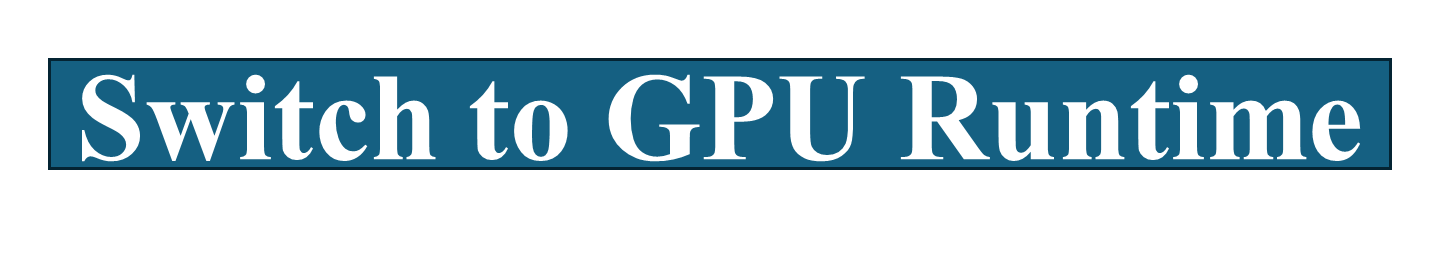

# **11. Switch to GPU Runtime**

Stop here before running deep-learning steps.

1. Save the CPU checkpoint above.
2. In Colab, choose **Runtime -> Change runtime type -> GPU**.
3. After the runtime restarts, run the GPU install cell.
4. Choose the LLM decision model in the new model-selection cell.
5. Restore the CPU checkpoint, then continue with reranking, chunking, and LLM review.


In [ ]:
# @title Install GPU/deep-learning packages
import subprocess
import sys
import csv
import io
import json
import os
import re
import shutil
import time
import xml.etree.ElementTree as ET
from collections import Counter, defaultdict
from dataclasses import dataclass, field
from getpass import getpass
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd
import requests
from IPython.display import HTML, display
from tqdm.auto import tqdm

try:
    import ipywidgets as widgets
except Exception:
    widgets = None

from IPython.display import HTML, display

In [ ]:

if "success_card" not in globals():
    def card(title, body="", accent="#2563eb"):
        display(HTML(f"""
        <div style="border:1px solid #d9e2ec;border-left:6px solid {accent};
                    border-radius:10px;padding:16px 18px;margin:12px 0;background:#fbfdff;">
          <h3 style="margin:0 0 6px 0;color:#0f172a;font-size:18px;">{title}</h3>
          <p style="margin:4px 0;color:#334155;line-height:1.45;">{body}</p>
        </div>
        """))

    def warning_card(title, body):
        card(title, body, accent="#d97706")

    def success_card(title, body):
        card(title, body, accent="#16a34a")


subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "-q",
    "transformers",
    "sentence-transformers",
    "accelerate",
    "sentencepiece",
])

try:
    import torch
    gpu_available = torch.cuda.is_available()
    gpu_name = torch.cuda.get_device_name(0) if gpu_available else "No GPU detected"
except Exception as exc:
    gpu_available = False
    gpu_name = f"Could not check GPU: {exc}"

if gpu_available:
    success_card("GPU runtime is ready", gpu_name)
else:
    warning_card(
        "GPU not detected",
        "You can continue on CPU, but tokenization/reranking/free T5 may be slow. Check Runtime -> Change runtime type -> GPU."
    )


## 11A. Choose LLM Decision Model

Choose the model that will make the final True/False decision on article chunks.

- **Free LongT5** uses `google/long-t5-tglobal-base`, does not ask for an API key, and uses a 2,048-token input budget.
- **DeepSeek Reasoner**, **OpenAI**, and **Gemini** ask for an API key and use a 30,000-token input budget.

The notebook uses this token budget to decide how many rows/chunks are sent to the LLM in each request.


In [ ]:
# @title LLM decision model settings
llm_decision_model_choice = "Free LongT5 (no API key)"  # @param ["Free LongT5 (no API key)", "DeepSeek Reasoner API", "OpenAI API", "Gemini API"]
openai_model_name = "gpt-4o-mini"  # @param {type:"string"}
gemini_model_name = "gemini-2.5-flash"  # @param {type:"string"}
deepseek_model_name = "deepseek-reasoner"  # @param {type:"string"}

from getpass import getpass
import os

FREE_LONGT5_MODEL_NAME = "google/long-t5-tglobal-base"
FREE_T5_MODEL_NAME = FREE_LONGT5_MODEL_NAME
FREE_T5_MAX_NEW_TOKENS = 64

LLM_TEMPERATURE = 0
LLM_TIMEOUT_SECONDS = 180
LLM_MAX_OUTPUT_TOKENS = 3000

COMMERCIAL_LLM_CONFIGS = {
    "deepseek": {
        "api_key_env": "DEEPSEEK_API_KEY",
        "base_url": "https://api.deepseek.com/chat/completions",
        "model": deepseek_model_name.strip() or "deepseek-reasoner",
        "api_type": "openai_compatible",
    },
    "openai": {
        "api_key_env": "OPENAI_API_KEY",
        "base_url": "https://api.openai.com/v1/chat/completions",
        "model": openai_model_name.strip() or "gpt-4o-mini",
        "api_type": "openai_compatible",
    },
    "gemini": {
        "api_key_env": "GEMINI_API_KEY",
        "base_url": "https://generativelanguage.googleapis.com/v1beta/models",
        "model": gemini_model_name.strip() or "gemini-2.5-flash",
        "api_type": "gemini",
    },
}

if llm_decision_model_choice == "Free LongT5 (no API key)":
    LLM_PROVIDER = "free_longt5"
    LLM_REQUIRES_API_KEY = False
    LLM_MODEL_NAME = FREE_LONGT5_MODEL_NAME
    LLM_MAX_INPUT_ESTIMATED_TOKENS = 2048
    LLM_MAX_ROWS_PER_BATCH = 1
    LLM_BATCHING_MODE = "one_row_per_call"
elif llm_decision_model_choice == "DeepSeek Reasoner API":
    LLM_PROVIDER = "deepseek"
    LLM_REQUIRES_API_KEY = True
    LLM_MODEL_NAME = COMMERCIAL_LLM_CONFIGS[LLM_PROVIDER]["model"]
    LLM_MAX_INPUT_ESTIMATED_TOKENS = 30000
    LLM_MAX_ROWS_PER_BATCH = 1000000
    LLM_BATCHING_MODE = "whole_subgroup_until_token_limit"
elif llm_decision_model_choice == "OpenAI API":
    LLM_PROVIDER = "openai"
    LLM_REQUIRES_API_KEY = True
    LLM_MODEL_NAME = COMMERCIAL_LLM_CONFIGS[LLM_PROVIDER]["model"]
    LLM_MAX_INPUT_ESTIMATED_TOKENS = 30000
    LLM_MAX_ROWS_PER_BATCH = 1000000
    LLM_BATCHING_MODE = "whole_subgroup_until_token_limit"
elif llm_decision_model_choice == "Gemini API":
    LLM_PROVIDER = "gemini"
    LLM_REQUIRES_API_KEY = True
    LLM_MODEL_NAME = COMMERCIAL_LLM_CONFIGS[LLM_PROVIDER]["model"]
    LLM_MAX_INPUT_ESTIMATED_TOKENS = 30000
    LLM_MAX_ROWS_PER_BATCH = 1000000
    LLM_BATCHING_MODE = "whole_subgroup_until_token_limit"
else:
    raise ValueError(f"Unknown LLM model choice: {llm_decision_model_choice}")

if LLM_REQUIRES_API_KEY:
    env_name = COMMERCIAL_LLM_CONFIGS[LLM_PROVIDER]["api_key_env"]
    if not os.getenv(env_name, "").strip():
        api_key = getpass(f"Paste {env_name}: ").strip()
        if not api_key:
            raise ValueError(f"{env_name} is required for {llm_decision_model_choice}.")
        os.environ[env_name] = api_key

if "success_card" in globals():
    success_card("LLM decision model saved", "The LLM batching size will follow this model's input-token budget.")
if "metric_cards" in globals():
    metric_cards([
        ("LLM provider", LLM_PROVIDER),
        ("Model", LLM_MODEL_NAME),
        ("Requires API key", LLM_REQUIRES_API_KEY),
        ("Max input tokens", f"{LLM_MAX_INPUT_ESTIMATED_TOKENS:,}"),
        ("Batching mode", LLM_BATCHING_MODE),
        ("Max rows per batch", "1" if LLM_BATCHING_MODE == "one_row_per_call" else "all rows until token limit"),
    ])
else:
    print("LLM provider:", LLM_PROVIDER)
    print("Model:", LLM_MODEL_NAME)
    print("Requires API key:", LLM_REQUIRES_API_KEY)
    print("Max input tokens:", LLM_MAX_INPUT_ESTIMATED_TOKENS)
    print("Batching mode:", LLM_BATCHING_MODE)
    print("Max rows per batch:", "1" if LLM_BATCHING_MODE == "one_row_per_call" else "all rows until token limit")


## 12. Restore CPU Checkpoint in GPU Runtime

Use this after switching to GPU. It reloads the saved CPU outputs and recreates the variables needed for tokenization, chunking, ranking, and LLM review.


In [ ]:
import shutil
from pathlib import Path
import pandas as pd
from google.colab import files
from IPython.display import HTML, display

In [ ]:
# @title Restore CPU checkpoint
restore_source = "Google Drive zip path"  # @param ["Google Drive zip path", "Upload zip", "Already restored / files are present"]
checkpoint_zip_path = "/content/open_access_screening_cpu_checkpoint_20260616_103557.zip"  # @param {type:"string"}

from google.colab import files

def set_project_paths(project_root):
    global PROJECT_ROOT, XML_DIR, OUTPUT_DIR, SRC_DIR
    PROJECT_ROOT = Path(project_root)
    XML_DIR = PROJECT_ROOT / "downloaded_articles"
    OUTPUT_DIR = PROJECT_ROOT / "output"
    SRC_DIR = PROJECT_ROOT / "src"
    for folder in [XML_DIR, OUTPUT_DIR, SRC_DIR]:
        folder.mkdir(parents=True, exist_ok=True)


if "PROJECT_ROOT" not in globals():
    set_project_paths("/content/emnlp_open_access_screening")
else:
    set_project_paths(PROJECT_ROOT)

if restore_source == "Google Drive zip path":
    if not checkpoint_zip_path.strip():
        raise ValueError("Paste the Google Drive checkpoint zip path.")
    from google.colab import drive
    drive.mount("/content/drive")
    source_zip = Path(checkpoint_zip_path)
    if not source_zip.exists():
        raise FileNotFoundError(f"Checkpoint zip not found: {source_zip}")
    shutil.unpack_archive(str(source_zip), str(PROJECT_ROOT), "zip")
elif restore_source == "Upload zip":
    uploaded = files.upload()
    if not uploaded:
        raise ValueError("No checkpoint zip was uploaded.")
    uploaded_name = next(iter(uploaded.keys()))
    source_zip = Path("/content") / uploaded_name
    source_zip.write_bytes(uploaded[uploaded_name])
    shutil.unpack_archive(str(source_zip), str(PROJECT_ROOT), "zip")
else:
    source_zip = None

keyword_csv = OUTPUT_DIR / "step4_keyword_matched.csv"
if not keyword_csv.exists():
    matching_keyword_files = sorted(PROJECT_ROOT.rglob("step4_keyword_matched.csv"))
    if matching_keyword_files:
        keyword_csv = matching_keyword_files[0]
        OUTPUT_DIR = keyword_csv.parent
        if OUTPUT_DIR.name == "output":
            PROJECT_ROOT = OUTPUT_DIR.parent
            XML_DIR = PROJECT_ROOT / "downloaded_articles"
            SRC_DIR = PROJECT_ROOT / "src"
    else:
        raise FileNotFoundError(
            "Could not find step4_keyword_matched.csv after restore. "
            "After changing runtime, /content is empty. Choose 'Google Drive zip path' "
            "and paste the checkpoint zip path, or choose 'Upload zip' and upload the CPU checkpoint."
        )

keyword_matched_df = pd.read_csv(keyword_csv, dtype={"pmc_id": str})

pattern_summary_path = OUTPUT_DIR / "step4_keyword_pattern_summary.csv"
pattern_summary_df = pd.read_csv(pattern_summary_path) if pattern_summary_path.exists() else pd.DataFrame()

section_selection_path = OUTPUT_DIR / "section_selection.csv"
section_selection_df = pd.read_csv(section_selection_path) if section_selection_path.exists() else pd.DataFrame()

if "metric_cards" not in globals():
    def metric_cards(metrics):
        rows = []
        for label, value in metrics:
            rows.append(
                f"<div style='border:1px solid #e2e8f0;border-radius:10px;padding:12px;background:white;'>"
                f"<div style='font-size:22px;font-weight:700;color:#0f172a;'>{value}</div>"
                f"<div style='font-size:12px;color:#64748b;text-transform:uppercase;'>{label}</div>"
                "</div>"
            )
        display(HTML(
            "<div style='display:grid;grid-template-columns:repeat(auto-fit,minmax(170px,1fr));gap:10px;margin:12px 0;'>"
            + "".join(rows)
            + "</div>"
        ))


success_card(
    "CPU checkpoint restored",
    "The GPU phase will use step4_keyword_matched.csv from the restored CPU outputs."
)
metric_cards([
    ("Keyword rows", f"{len(keyword_matched_df):,}"),
    ("Keyword PMC IDs", f"{keyword_matched_df['pmc_id'].dropna().astype(str).nunique():,}"),
    ("Output folder", str(OUTPUT_DIR)),
])
display(keyword_matched_df.head())


## 13. Reranker and Chunking Settings

Choose the reranker and token limits. The chunk size depends on the chosen model.


In [ ]:
# @title Reranker and chunking settings
reranker_choice = "MedCPT CrossEncoder"  # @param ["MedCPT CrossEncoder", "Custom CrossEncoder", "Skip reranking"]
custom_cross_encoder_model = ""  # @param {type:"string"}
custom_model_max_tokens = 512  # @param {type:"integer"}
chunk_overlap_ratio = 0.15  # @param {type:"number"}

PUBMEDBERT_TOKENIZER = "microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext"
SPECIAL_TOKENS = 3
MEDCPT_BATCH_SIZE = 32
CHUNK_OVERLAP_RATIO = float(chunk_overlap_ratio)

if reranker_choice == "MedCPT CrossEncoder":
    RUN_MEDCPT_RERANKING = True
    MEDCPT_MODEL_NAME = "ncbi/MedCPT-Cross-Encoder"
    MODEL_MAX_TOKENS = 512
elif reranker_choice == "Custom CrossEncoder":
    if not custom_cross_encoder_model.strip():
        raise ValueError("Enter a custom CrossEncoder model name.")
    RUN_MEDCPT_RERANKING = True
    MEDCPT_MODEL_NAME = custom_cross_encoder_model.strip()
    MODEL_MAX_TOKENS = int(custom_model_max_tokens)
else:
    RUN_MEDCPT_RERANKING = False
    MEDCPT_MODEL_NAME = ""
    MODEL_MAX_TOKENS = int(custom_model_max_tokens)

if "LLM_PROVIDER" not in globals():
    raise ValueError("Run Step 11A first so subgroup limits can match the selected LLM decision model.")

if LLM_PROVIDER == "free_longt5":
    # LongT5 is called one row at a time, so subgroup CSV files do not need a 30k API limit.
    SPLIT_GROUPS_ABOVE_TOKENS = 1_000_000_000
    MAX_SUBGROUP_TOKENS = 1_000_000_000
    SUBGROUP_LIMIT_DESCRIPTION = "Free LongT5: no API subgroup limit; one row is sent per model call"
else:
    # API models should receive whole subgroup files when possible, but each subgroup must stay under 30k.
    MAX_SUBGROUP_TOKENS = int(LLM_MAX_INPUT_ESTIMATED_TOKENS)
    SPLIT_GROUPS_ABOVE_TOKENS = MAX_SUBGROUP_TOKENS - 1
    SUBGROUP_LIMIT_DESCRIPTION = f"{LLM_PROVIDER}: split subgroup files so each API call stays under {MAX_SUBGROUP_TOKENS:,} estimated input tokens"

card("Reranker settings saved", "Chunking will use the selected reranker token limit. LLM subgroup limits come from Step 11A.")
metric_cards([
    ("Reranking", RUN_MEDCPT_RERANKING),
    ("Reranker model", MEDCPT_MODEL_NAME if MEDCPT_MODEL_NAME else "none"),
    ("Reranker max tokens", MODEL_MAX_TOKENS),
    ("Chunk overlap", CHUNK_OVERLAP_RATIO),
    ("LLM model", LLM_MODEL_NAME),
    ("LLM input limit", f"{LLM_MAX_INPUT_ESTIMATED_TOKENS:,}"),
    ("Subgroup strategy", SUBGROUP_LIMIT_DESCRIPTION),
])


## 14. Reranking Query

Describe the evidence the reranker should prioritize. Enter one query per line.


In [ ]:
try:
    import ipywidgets as widgets
except Exception:
    widgets = None


if widgets is None:
    RERANK_QUERIES = []
    print("Enter reranking queries. Leave blank when finished.")
    while True:
        query = input(f"Reranking query {len(RERANK_QUERIES) + 1}: ").strip()
        if not query:
            break
        RERANK_QUERIES.append(query)
else:
    rerank_query_box = widgets.Textarea(
        value="",
        placeholder="Example:\nreports the numerical result required by my review question",
        description="Queries:",
        layout=widgets.Layout(width="95%", height="110px"),
    )
    display(rerank_query_box)


In [ ]:
try:
    import ipywidgets as widgets
except Exception:
    widgets = None

if widgets is not None and "rerank_query_box" in globals():
    RERANK_QUERIES = [line.strip() for line in rerank_query_box.value.splitlines() if line.strip()]
elif "RERANK_QUERIES" not in globals():
    RERANK_QUERIES = []

if not RERANK_QUERIES:
    raise ValueError("Please enter at least one reranking query.")

success_card("Reranking queries saved", "These queries will be paired with each chunk for ranking.")
display(pd.DataFrame({"query_number": range(1, len(RERANK_QUERIES) + 1), "query": RERANK_QUERIES}))


## 15. Tokenize and Create Safe Chunks

This keeps chunk length compatible with your chosen reranking model.


In [ ]:
from transformers import AutoTokenizer
from tqdm.auto import tqdm


if keyword_matched_df.empty:
    raise ValueError("No keyword-matched rows. Adjust keyword terms, section choices, or earlier filters.")

queries = [query.strip() for query in RERANK_QUERIES if query.strip()]
tokenizer = AutoTokenizer.from_pretrained(PUBMEDBERT_TOKENIZER, use_fast=True)
query_token_counts = [len(tokenizer(query, add_special_tokens=False)["input_ids"]) for query in queries]
max_query_tokens = max(query_token_counts)

tokenized_df = keyword_matched_df.copy()
token_ids_json = []
token_offsets_json = []
token_counts = []

for text in tqdm(tokenized_df["text"].fillna("").astype(str), desc="Tokenizing paragraphs"):
    encoded = tokenizer(text, add_special_tokens=False, return_offsets_mapping=True)
    token_ids_json.append(json.dumps(encoded["input_ids"]))
    token_offsets_json.append(json.dumps(encoded["offset_mapping"]))
    token_counts.append(len(encoded["input_ids"]))

tokenized_df["paragraph_token_count"] = token_counts
tokenized_df["paragraph_token_ids_json"] = token_ids_json
tokenized_df["paragraph_token_offsets_json"] = token_offsets_json
tokenized_df["query_texts"] = " || ".join(queries)
tokenized_df["query_token_counts"] = " || ".join(map(str, query_token_counts))
tokenized_df["max_query_tokens"] = max_query_tokens
tokenized_df["tokenizer_name"] = PUBMEDBERT_TOKENIZER
tokenized_df.to_csv(OUTPUT_DIR / "step5_tokenized_paragraphs_pubmedbert.csv", index=False, encoding="utf-8-sig")


def parse_json_list(value, field_name):
    parsed = json.loads(str(value))
    if not isinstance(parsed, list):
        raise ValueError(f"{field_name} must decode to a JSON list.")
    return parsed


def chunk_text_from_offsets(text, offsets, start, end):
    selected = offsets[start:end]
    if not selected:
        return ""
    start_char = selected[0][0]
    end_char = selected[-1][1]
    if start_char is None or end_char is None or int(end_char) <= int(start_char):
        return ""
    return str(text)[int(start_char):int(end_char)].strip()


def create_chunks_from_tokenized(df):
    body_token_budget = int(MODEL_MAX_TOKENS) - int(max_query_tokens) - int(SPECIAL_TOKENS)
    if body_token_budget <= 0:
        raise ValueError("Token budget is <= 0. Reduce query length or increase model max tokens.")
    overlap_tokens = int(round(body_token_budget * float(CHUNK_OVERLAP_RATIO)))
    overlap_tokens = max(0, min(overlap_tokens, body_token_budget - 1))
    stride_tokens = body_token_budget - overlap_tokens
    rows = []
    for _, row in tqdm(df.iterrows(), total=len(df), desc="Creating chunks"):
        token_ids = parse_json_list(row["paragraph_token_ids_json"], "paragraph_token_ids_json")
        offsets = parse_json_list(row["paragraph_token_offsets_json"], "paragraph_token_offsets_json")
        text = str(row.get("text", ""))
        pre_chunk_name = str(row.get("passage_name") or f"{row.get('pmc_id', 'UNKNOWN')}_offset_{row.get('offset', 0)}")
        start = 0
        chunk_index = 1
        while start < len(token_ids):
            end = min(start + body_token_budget, len(token_ids))
            chunk_ids = token_ids[start:end]
            chunk_text = chunk_text_from_offsets(text, offsets, start, end) or text
            new_row = row.to_dict()
            new_row.update({
                "pre_chunk_name": pre_chunk_name,
                "chunk_name": f"{pre_chunk_name}_chunk{chunk_index:03d}",
                "chunk_index": chunk_index,
                "chunk_start_token": start + 1,
                "chunk_end_token": end,
                "chunk_token_count": len(chunk_ids),
                "chunk_text": chunk_text,
                "chunk_token_ids_json": json.dumps(chunk_ids),
                "model_max_tokens": MODEL_MAX_TOKENS,
                "chunk_token_budget": body_token_budget,
                "overlap_ratio": CHUNK_OVERLAP_RATIO,
                "overlap_tokens": overlap_tokens,
                "stride_tokens": stride_tokens,
            })
            rows.append(new_row)
            if end >= len(token_ids):
                break
            start += stride_tokens
            chunk_index += 1
    return pd.DataFrame(rows)


chunks_df = create_chunks_from_tokenized(tokenized_df)
chunks_df.to_csv(OUTPUT_DIR / "step6_chunks.csv", index=False, encoding="utf-8-sig")

success_card("Tokenization and chunking finished", "Chunks are ready for reranking.")
metric_cards([
    ("Tokenized rows", f"{len(tokenized_df):,}"),
    ("Chunks created", f"{len(chunks_df):,}"),
    ("Max query tokens", max_query_tokens),
    ("Max chunk tokens", int(pd.to_numeric(chunks_df["chunk_token_count"], errors="coerce").max())),
])
display(chunks_df.head())


## 16. Rerank Chunks

MedCPT or your selected CrossEncoder scores each chunk against your reranking query.


In [ ]:
if RUN_MEDCPT_RERANKING:
    from sentence_transformers import CrossEncoder
    model = CrossEncoder(MEDCPT_MODEL_NAME, max_length=MODEL_MAX_TOKENS)
    chunk_texts = chunks_df["chunk_text"].fillna("").astype(str).tolist()
    all_scores = []
    for query in queries:
        pairs = [(query, chunk_text) for chunk_text in chunk_texts]
        scores = model.predict(pairs, batch_size=MEDCPT_BATCH_SIZE, show_progress_bar=True)
        all_scores.append(np.asarray(scores))
    score_matrix = np.vstack(all_scores)
    best_query_idx = score_matrix.argmax(axis=0)
    chunks_scored_df = chunks_df.copy()
    chunks_scored_df["medcpt_best_query"] = [queries[i] for i in best_query_idx]
    chunks_scored_df["medcpt_score"] = score_matrix.max(axis=0)
else:
    chunks_scored_df = chunks_df.copy()
    chunks_scored_df["medcpt_best_query"] = queries[0]
    chunks_scored_df["medcpt_score"] = 0.0

chunks_scored_df["medcpt_rank"] = chunks_scored_df["medcpt_score"].rank(method="first", ascending=False).astype(int)
chunks_scored_df.to_csv(OUTPUT_DIR / "step7_chunks_scored_medcpt.csv", index=False, encoding="utf-8-sig")

if "display_counts" not in globals():
    def display_counts(label, df, pmc_col="pmc_id"):
        metrics = [("Rows", f"{len(df):,}")]
        if pmc_col in df.columns:
            metrics.append(("Unique PMC IDs", f"{df[pmc_col].dropna().astype(str).nunique():,}"))

        if "card" in globals():
            card(label, "Preview of the current dataset.")
        else:
            print(label)

        if "metric_cards" in globals():
            metric_cards(metrics)
        else:
            print(" | ".join([f"{label}: {value}" for label, value in metrics]))

        display(df.head())

success_card("Reranking finished", "The highest-scoring chunks will be reviewed first.")
display_counts("Scored chunks", chunks_scored_df)
display(chunks_scored_df[["pmc_id", "chunk_name", "medcpt_best_query", "medcpt_score", "medcpt_rank"]].head(20))


## 17. Create Ranked Groups and Token-Budgeted Subgroups

Each article contributes its best chunk to group 1, second-best chunk to group 2, and so on. Large groups are split for LLM review.


In [ ]:
GROUP_DIR = OUTPUT_DIR / "medcpt_score_groups"
SUBGROUP_DIR = OUTPUT_DIR / "medcpt_score_subgroups"
PENDING_SUBGROUP_DIR = OUTPUT_DIR / "medcpt_score_subgroups_pending"
for folder in [GROUP_DIR, SUBGROUP_DIR, PENDING_SUBGROUP_DIR]:
    folder.mkdir(parents=True, exist_ok=True)
    for old in folder.glob("*.csv"):
        old.unlink()

if globals().get("LLM_REQUIRES_API_KEY", False):
    EFFECTIVE_MAX_SUBGROUP_TOKENS = int(globals().get("LLM_MAX_INPUT_ESTIMATED_TOKENS", MAX_SUBGROUP_TOKENS))
    EFFECTIVE_SPLIT_GROUPS_ABOVE_TOKENS = min(int(SPLIT_GROUPS_ABOVE_TOKENS), EFFECTIVE_MAX_SUBGROUP_TOKENS)
else:
    EFFECTIVE_MAX_SUBGROUP_TOKENS = int(MAX_SUBGROUP_TOKENS)
    EFFECTIVE_SPLIT_GROUPS_ABOVE_TOKENS = int(SPLIT_GROUPS_ABOVE_TOKENS)

ranked_df = chunks_scored_df.copy()
ranked_df["medcpt_score"] = pd.to_numeric(ranked_df["medcpt_score"], errors="coerce").fillna(-999)
ranked_df["paragraph_token_count"] = pd.to_numeric(ranked_df["paragraph_token_count"], errors="coerce").fillna(0).astype(int)
ranked_df = ranked_df.sort_values(["pmc_id", "medcpt_score", "chunk_name"], ascending=[True, False, True], kind="mergesort")
ranked_df["pmc_score_group"] = ranked_df.groupby("pmc_id", sort=False).cumcount() + 1

group_summary_rows = []
for group_number, group_df in ranked_df.groupby("pmc_score_group", sort=True):
    group_number = int(group_number)
    group_df = group_df.copy()
    total_tokens = int(group_df["paragraph_token_count"].sum())
    group_df["group_total_paragraph_token_count"] = total_tokens
    group_df["group_row_count"] = len(group_df)
    group_df["group_unique_pmc_count"] = group_df["pmc_id"].nunique()
    group_file = GROUP_DIR / f"group_{group_number:03d}.csv"
    group_df.to_csv(group_file, index=False, encoding="utf-8-sig")
    group_summary_rows.append({
        "group_number": group_number,
        "group_file": str(group_file),
        "row_count": len(group_df),
        "unique_pmc_count": group_df["pmc_id"].nunique(),
        "total_paragraph_token_count": total_tokens,
    })

group_summary_df = pd.DataFrame(group_summary_rows)
group_summary_df.to_csv(OUTPUT_DIR / "step8_medcpt_score_group_summary.csv", index=False, encoding="utf-8-sig")


def split_indices_by_token_budget(token_counts, max_subgroup_tokens):
    subgroups = []
    start_index = 0
    current_total = 0
    for row_index, token_count in enumerate(token_counts):
        token_count = int(token_count)
        if token_count >= max_subgroup_tokens:
            raise ValueError(f"One row has {token_count} tokens, above subgroup limit {max_subgroup_tokens}.")
        if current_total and current_total + token_count >= max_subgroup_tokens:
            subgroups.append((start_index, row_index, current_total))
            start_index = row_index
            current_total = 0
        current_total += token_count
    if current_total or not token_counts:
        subgroups.append((start_index, len(token_counts), current_total))
    return subgroups


subgroup_summary_rows = []
for _, group_row in group_summary_df.iterrows():
    group_number = int(group_row["group_number"])
    group_file = Path(group_row["group_file"])
    group_df = pd.read_csv(group_file, dtype={"pmc_id": str})
    group_df["paragraph_token_count"] = pd.to_numeric(group_df["paragraph_token_count"], errors="coerce").fillna(0).astype(int)
    group_total_tokens = int(group_df["paragraph_token_count"].sum())
    should_split = group_total_tokens > EFFECTIVE_SPLIT_GROUPS_ABOVE_TOKENS
    ranges = split_indices_by_token_budget(group_df["paragraph_token_count"].tolist(), EFFECTIVE_MAX_SUBGROUP_TOKENS) if should_split else [(0, len(group_df), group_total_tokens)]
    for subgroup_number, (start_index, end_index, subgroup_tokens) in enumerate(ranges, start=1):
        subgroup_df = group_df.iloc[start_index:end_index].copy()
        subgroup_name = f"group_{group_number:03d}_subgroup_{subgroup_number:03d}"
        subgroup_file = SUBGROUP_DIR / f"{subgroup_name}.csv"
        subgroup_df["source_group_number"] = group_number
        subgroup_df["subgroup_number"] = subgroup_number
        subgroup_df["subgroup_name"] = subgroup_name
        subgroup_df["subgroup_total_paragraph_token_count"] = int(subgroup_tokens)
        subgroup_df["llm_subgroup_token_limit"] = int(EFFECTIVE_MAX_SUBGROUP_TOKENS)
        subgroup_df.to_csv(subgroup_file, index=False, encoding="utf-8-sig")
        shutil.copy2(subgroup_file, PENDING_SUBGROUP_DIR / subgroup_file.name)
        subgroup_summary_rows.append({
            "source_group_number": group_number,
            "subgroup_number": subgroup_number,
            "subgroup_name": subgroup_name,
            "subgroup_file": str(subgroup_file),
            "row_count": len(subgroup_df),
            "unique_pmc_count": subgroup_df["pmc_id"].nunique(),
            "subgroup_total_paragraph_token_count": int(subgroup_tokens),
            "source_group_was_split": should_split,
            "llm_subgroup_token_limit": int(EFFECTIVE_MAX_SUBGROUP_TOKENS),
        })

subgroup_summary_df = pd.DataFrame(subgroup_summary_rows)
subgroup_summary_df.to_csv(OUTPUT_DIR / "step9_medcpt_score_subgroup_summary.csv", index=False, encoding="utf-8-sig")

success_card("Subgroups are ready", "These files are the units that will be sent to the LLM classifier.")
metric_cards([
    ("Groups", f"{len(group_summary_df):,}"),
    ("Subgroups", f"{len(subgroup_summary_df):,}"),
    ("Pending subgroup files", f"{len(list(PENDING_SUBGROUP_DIR.glob('*.csv'))):,}"),
    ("Subgroup token limit", f"{EFFECTIVE_MAX_SUBGROUP_TOKENS:,}"),
])
display(subgroup_summary_df.head(20))


## 18. Confirm LLM Classifier Settings

This step confirms the model selected at the start of the GPU phase. The row batching is controlled by the selected model's input-token budget.


In [ ]:
# @title Confirm LLM classifier settings
if "LLM_PROVIDER" not in globals():
    raise ValueError("Run Step 11A first to choose the LLM decision model.")

if LLM_PROVIDER == "free_longt5":
    FREE_T5_MODEL_NAME = FREE_LONGT5_MODEL_NAME
    FREE_T5_MAX_NEW_TOKENS = 64
else:
    config = COMMERCIAL_LLM_CONFIGS[LLM_PROVIDER]
    env_name = config["api_key_env"]
    if not os.getenv(env_name, "").strip():
        api_key = getpass(f"Paste {env_name}: ").strip()
        if not api_key:
            raise ValueError(f"{env_name} is required for {LLM_PROVIDER}.")
        os.environ[env_name] = api_key

LLM_BATCH_SIZE = int(globals().get("LLM_MAX_ROWS_PER_BATCH", 1))
LLM_BATCH_DESCRIPTION = "1 row per model call" if LLM_PROVIDER == "free_longt5" else f"whole subgroup until {LLM_MAX_INPUT_ESTIMATED_TOKENS:,} estimated input tokens"
LLM_MAX_OUTPUT_TOKENS = int(globals().get("LLM_MAX_OUTPUT_TOKENS", 3000))
LLM_TEMPERATURE = float(globals().get("LLM_TEMPERATURE", 0))
LLM_TIMEOUT_SECONDS = int(globals().get("LLM_TIMEOUT_SECONDS", 180))

success_card("LLM settings confirmed", "The classifier will batch rows according to the selected model.")
metric_cards([
    ("Provider", LLM_PROVIDER),
    ("Model", LLM_MODEL_NAME),
    ("Max input tokens", f"{LLM_MAX_INPUT_ESTIMATED_TOKENS:,}"),
    ("Batching", LLM_BATCH_DESCRIPTION),
    ("Max rows per batch", "1" if LLM_PROVIDER == "free_longt5" else "all rows until token limit"),
    ("API required", bool(globals().get("LLM_REQUIRES_API_KEY", False))),
])


## 19. Write the LLM Screening Question

Describe exactly what counts as relevant evidence in general terms.


In [ ]:
# @title LLM question and decision rules
llm_question = ""  # @param {type:"string"}
true_rule = ""  # @param {type:"string"}
false_rule = ""  # @param {type:"string"}

"""
Example
#llm_question = "Does this chunk report a numerical MIC, MIC50, MIC90, or minimum inhibitory concentration value?"  # @param {type:"string"}
#true_rule = "True if the chunk reports a numeric value clearly tied to MIC, MIC50, MIC90, or minimum inhibitory concentration."  # @param {type:"string"}
#false_rule = "False if no numeric MIC value is reported, or if MIC appears only as a method, abbreviation, background concept, heading, or non-result context."  # @param {type:"string"}

"""
LLM_QUESTION = llm_question.strip()
LLM_TRUE_RULE = true_rule.strip()
LLM_FALSE_RULE = false_rule.strip()

if not LLM_QUESTION or not LLM_TRUE_RULE or not LLM_FALSE_RULE:
    raise ValueError("Fill in the question, True rule, and False rule before continuing.")

success_card("LLM review instructions saved", "These instructions will be sent with each chunk batch.")
display(pd.DataFrame([
    {"field": "Question", "text": LLM_QUESTION},
    {"field": "True rule", "text": LLM_TRUE_RULE},
    {"field": "False rule", "text": LLM_FALSE_RULE},
]))


## 20. LLM Classification Functions

The classifier sends only `pmc_id` and `chunk_text` to the model. Output files keep section type and evidence for auditing.


In [ ]:
import json
import os
import re
import time
from collections import defaultdict
from getpass import getpass
from pathlib import Path

import pandas as pd
import requests
from IPython.display import HTML, display


if "chunks" not in globals():
    def chunks(values, size):
        values = list(values)
        for start in range(0, len(values), size):
            yield values[start:start + size]


if "clean_text_for_csv" not in globals():
    def clean_text_for_csv(value):
        return str(value or "").replace("\r", " ").replace("\n", " ").strip()

In [ ]:
import json
import os
import re
import time
from collections import defaultdict
from getpass import getpass
from pathlib import Path

import pandas as pd
import requests

LLM_RESULT_DIR = OUTPUT_DIR / "llm_results"
LLM_RESULT_DIR.mkdir(parents=True, exist_ok=True)

RELEVANT_PMC_CSV = OUTPUT_DIR / "llm_relevant_pmc_ids.csv"
PROCESSED_SUBGROUPS_CSV = OUTPUT_DIR / "llm_processed_subgroups.csv"
PENDING_SUMMARY_CSV = OUTPUT_DIR / "llm_pending_subgroup_summary.csv"

if "clean_text_for_csv" not in globals():
    def clean_text_for_csv(value):
        if value is None or (isinstance(value, float) and pd.isna(value)):
            return ""
        text = str(value).replace("\r", " ").replace("\n", " ")
        return re.sub(r"\s+", " ", text).strip()


def subgroup_sort_key(path):
    match = re.search(r"group_(\d+)_subgroup_(\d+)", path.stem)
    if not match:
        return (10**9, 10**9, path.name)
    return (int(match.group(1)), int(match.group(2)), path.name)


def list_pending_subgroups():
    return sorted(PENDING_SUBGROUP_DIR.glob("group_*_subgroup_*.csv"), key=subgroup_sort_key)


def make_binary_prompt_for_items(items):
    safe_items = [
        {"pmc_id": str(item.get("pmc_id", "")), "chunk_text": str(item.get("chunk_text", ""))}
        for item in items
    ]
    return f"""
You are a strict biomedical evidence classifier.

Question: {LLM_QUESTION}
True rule: {LLM_TRUE_RULE}
False rule: {LLM_FALSE_RULE}

Classify each input item using only its pmc_id and chunk_text.
Do not invent values. Do not mark an item True unless a numeric value is clearly reported for MIC, MIC50, MIC90, or minimum inhibitory concentration.

Return only valid JSON in this exact format:
{{"results":[{{"pmc_id":"...","decision":"True","evidence":"one short sentence"}}]}}

Rules:
- Return exactly one result for each input item, in the same order.
- decision must be exactly "True" or "False".
- evidence must be one very short sentence explaining the decision.
- If evidence is ambiguous, incomplete, corrupted, or impossible to interpret, answer False.

Items:
{json.dumps(safe_items, ensure_ascii=False)}
""".strip()


def estimate_text_tokens(text):
    return max(1, (len(str(text or "")) + 3) // 4)


def estimate_items_tokens(items):
    return estimate_text_tokens(make_binary_prompt_for_items(items)) + 100


def split_rows_for_llm(source_df):
    records = list(source_df.to_dict(orient="records"))
    if globals().get("LLM_PROVIDER") == "free_longt5":
        return [pd.DataFrame([row]) for row in records]

    batches = []
    current = []
    max_rows = int(globals().get("LLM_BATCH_SIZE", globals().get("LLM_MAX_ROWS_PER_BATCH", 1000000)))
    max_input_tokens = int(globals().get("LLM_MAX_INPUT_ESTIMATED_TOKENS", 30000))

    for row in records:
        candidate = current + [row]
        candidate_items = [
            {"pmc_id": str(item["pmc_id"]), "chunk_text": str(item["chunk_text"])}
            for item in candidate
        ]
        over_rows = len(candidate) > max_rows
        over_tokens = estimate_items_tokens(candidate_items) > max_input_tokens
        if current and (over_rows or over_tokens):
            batches.append(pd.DataFrame(current))
            current = [row]
        else:
            current = candidate

    if current:
        batches.append(pd.DataFrame(current))
    return batches


def extract_json_from_text(text):
    content = (text or "").strip()
    if content.startswith("```"):
        content = re.sub(r"^```(?:json)?", "", content, flags=re.IGNORECASE).strip()
        content = re.sub(r"```$", "", content).strip()
    try:
        return json.loads(content)
    except json.JSONDecodeError:
        pass
    decoder = json.JSONDecoder()
    for match in re.finditer(r"[\{\[]", content):
        try:
            parsed, _ = decoder.raw_decode(content[match.start():])
            return parsed
        except json.JSONDecodeError:
            continue
    raise ValueError(f"Could not parse JSON response preview: {content[:500]}")


def normalize_decision(value):
    text = str(value or "").strip().lower()
    text = re.sub(r"\s+", " ", text)
    explicit = re.search(r"\b(?:decision|answer|classification|label)\s*[:=]?\s*[\"']?(true|false)\b", text)
    if explicit:
        return explicit.group(1).capitalize()
    if text in {"true", "yes", "y", "1", "relevant", "positive"} or text.startswith("true"):
        return "True"
    if text in {"false", "no", "n", "0", "not relevant", "irrelevant", "negative"} or text.startswith("false"):
        return "False"
    true_pos = text.find("true")
    false_pos = text.find("false")
    if true_pos >= 0 and (false_pos < 0 or true_pos < false_pos):
        return "True"
    return "False"


def clean_short_evidence(value, decision="False"):
    text = clean_text_for_csv(value)
    text = re.sub(r"^\s*(?:decision|answer|classification|label)\s*[:=]?\s*(?:true|false)\s*[.;,\-]*\s*", "", text, flags=re.IGNORECASE)
    text = re.sub(r"^\s*(?:evidence|reason|explanation)\s*[:=]?\s*", "", text, flags=re.IGNORECASE)
    if not text:
        return "Reports a numeric MIC value." if decision == "True" else "No numeric MIC value is reported."
    return text[:240].rstrip() + ("..." if len(text) > 240 else "")


def records_from_llm_json(payload):
    if isinstance(payload, list):
        records = payload
    elif isinstance(payload, dict) and isinstance(payload.get("results"), list):
        records = payload["results"]
    else:
        raise ValueError("LLM response must be a JSON list or {'results': [...]} object.")
    cleaned = []
    for record in records:
        if not isinstance(record, dict):
            record = {"decision": record}
        decision = normalize_decision(record.get("decision", record.get("answer", record.get("label", ""))))
        evidence = clean_short_evidence(
            record.get("evidence", record.get("reason", record.get("explanation", ""))),
            decision=decision,
        )
        cleaned.append({
            "pmc_id": str(record.get("pmc_id", record.get("pmcid", ""))).strip(),
            "decision": decision,
            "evidence": evidence,
        })
    return cleaned


def get_commercial_api_key(provider):
    config = COMMERCIAL_LLM_CONFIGS[provider]
    env_name = config["api_key_env"]
    key = os.getenv(env_name, "")
    if not key:
        key = getpass(f"Paste {env_name}: ").strip()
        if not key:
            raise ValueError(f"{env_name} is required for {provider}.")
        os.environ[env_name] = key
    return key


def call_openai_compatible_chat(provider, items):
    config = COMMERCIAL_LLM_CONFIGS[provider]
    api_key = get_commercial_api_key(provider)
    payload = {
        "model": config["model"],
        "messages": [
            {"role": "system", "content": "Return only JSON. Classify biomedical evidence carefully."},
            {"role": "user", "content": make_binary_prompt_for_items(items)},
        ],
        "temperature": LLM_TEMPERATURE,
        "max_tokens": LLM_MAX_OUTPUT_TOKENS,
        "response_format": {"type": "json_object"},
    }
    response = requests.post(
        config["base_url"],
        headers={"Authorization": f"Bearer {api_key}", "Content-Type": "application/json"},
        json=payload,
        timeout=LLM_TIMEOUT_SECONDS,
    )
    response.raise_for_status()
    data = response.json()
    return data["choices"][0]["message"].get("content", "")


def call_gemini_generate_content(items):
    config = COMMERCIAL_LLM_CONFIGS["gemini"]
    api_key = get_commercial_api_key("gemini")
    model = config["model"]
    url = f"{config['base_url']}/{model}:generateContent?key={api_key}"
    payload = {
        "contents": [
            {
                "role": "user",
                "parts": [{"text": make_binary_prompt_for_items(items)}],
            }
        ],
        "generationConfig": {
            "temperature": LLM_TEMPERATURE,
            "maxOutputTokens": LLM_MAX_OUTPUT_TOKENS,
            "responseMimeType": "application/json",
        },
    }
    response = requests.post(
        url,
        headers={"Content-Type": "application/json"},
        json=payload,
        timeout=LLM_TIMEOUT_SECONDS,
    )
    response.raise_for_status()
    data = response.json()
    candidates = data.get("candidates", [])
    if not candidates:
        raise ValueError(f"Gemini returned no candidates: {data}")
    parts = candidates[0].get("content", {}).get("parts", [])
    return "".join(str(part.get("text", "")) for part in parts)


_t5_assets = None


def get_t5_assets():
    global _t5_assets
    if _t5_assets is None:
        import torch
        from transformers import AutoModelForSeq2SeqLM, AutoTokenizer

        tokenizer = AutoTokenizer.from_pretrained(FREE_T5_MODEL_NAME)
        model = AutoModelForSeq2SeqLM.from_pretrained(FREE_T5_MODEL_NAME)
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        model.to(device)
        model.eval()
        _t5_assets = {"tokenizer": tokenizer, "model": model, "device": device}
    return _t5_assets


def classify_one_with_t5(row):
    assets = get_t5_assets()
    tokenizer = assets["tokenizer"]
    model = assets["model"]
    device = assets["device"]
    prompt = f"""
You are a strict biomedical evidence classifier.
Question: {LLM_QUESTION}
True rule: {LLM_TRUE_RULE}
False rule: {LLM_FALSE_RULE}

Use only the pmc_id and chunk_text below.
Return exactly two lines:
Decision: True or False
Evidence: one short sentence

pmc_id: {row['pmc_id']}
chunk_text: {row['chunk_text']}
""".strip()
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=int(LLM_MAX_INPUT_ESTIMATED_TOKENS),
    ).to(device)
    generated_ids = model.generate(
        **inputs,
        max_new_tokens=FREE_T5_MAX_NEW_TOKENS,
        do_sample=False,
    )
    output = tokenizer.decode(generated_ids[0], skip_special_tokens=True)
    decision = normalize_decision(output)
    return {
        "pmc_id": str(row["pmc_id"]),
        "decision": decision,
        "evidence": clean_short_evidence(output, decision=decision),
    }


def classify_batch(items):
    if LLM_PROVIDER == "free_longt5":
        return [classify_one_with_t5(item) for item in items]
    if LLM_PROVIDER in {"deepseek", "openai"}:
        response_text = call_openai_compatible_chat(LLM_PROVIDER, items)
        return records_from_llm_json(extract_json_from_text(response_text))
    if LLM_PROVIDER == "gemini":
        response_text = call_gemini_generate_content(items)
        return records_from_llm_json(extract_json_from_text(response_text))
    raise ValueError(f"Unsupported LLM_PROVIDER: {LLM_PROVIDER}")


def classify_subgroup_file(subgroup_file):
    source_df = pd.read_csv(subgroup_file, dtype={"pmc_id": str})
    required = {"pmc_id", "chunk_text"}
    missing = required - set(source_df.columns)
    if missing:
        raise ValueError(f"{subgroup_file} is missing: {sorted(missing)}")
    if "section_type" not in source_df.columns:
        source_df["section_type"] = ""
    if "medcpt_rank" in source_df.columns:
        source_df["medcpt_rank"] = pd.to_numeric(source_df["medcpt_rank"], errors="coerce")
        source_df = source_df.sort_values(["medcpt_rank", "pmc_id"], ascending=[True, True], kind="mergesort")

    subgroup_name = subgroup_file.stem
    all_result_rows = []
    source_df = source_df.reset_index(drop=True).copy()
    source_df["row_number_in_subgroup"] = range(1, len(source_df) + 1)

    llm_batches = split_rows_for_llm(source_df)
    for batch_number, batch_df in enumerate(llm_batches, start=1):
        batch_records = batch_df.to_dict(orient="records")
        items = [{"pmc_id": str(row["pmc_id"]), "chunk_text": str(row["chunk_text"])} for row in batch_records]
        records = classify_batch(items)
        records_by_pmc = defaultdict(list)
        for record in records:
            records_by_pmc[str(record.get("pmc_id", "")).strip()].append(record)
        for index, source_row in enumerate(batch_records):
            pmc_id = str(source_row["pmc_id"])
            model_row = {}
            if records_by_pmc.get(pmc_id):
                model_row = records_by_pmc[pmc_id].pop(0)
            elif index < len(records):
                model_row = records[index]
            decision = normalize_decision(model_row.get("decision"))
            evidence = clean_short_evidence(model_row.get("evidence", ""), decision=decision)
            all_result_rows.append({
                "subgroup_name": subgroup_name,
                "source_subgroup_file": str(subgroup_file),
                "row_number_in_subgroup": int(source_row["row_number_in_subgroup"]),
                "pmc_id": pmc_id,
                "section_type": str(source_row.get("section_type", "")),
                "medcpt_rank": source_row.get("medcpt_rank", ""),
                "medcpt_score": source_row.get("medcpt_score", ""),
                "chunk_text": str(source_row["chunk_text"]),
                "llm_provider": LLM_PROVIDER,
                "llm_model": LLM_MODEL_NAME,
                "llm_decision": decision,
                "llm_evidence": evidence,
                "is_relevant": decision,
                "decision_reason": evidence,
                "response_missing": bool(not model_row),
                "api_batch_number": batch_number,
                "api_batch_row_count": int(len(batch_df)),
                "api_batch_estimated_input_tokens": int(estimate_items_tokens(items)),
                "llm_max_input_estimated_tokens": int(LLM_MAX_INPUT_ESTIMATED_TOKENS),
            })

    result_df = pd.DataFrame(all_result_rows)
    if result_df["response_missing"].any():
        missing_count = int(result_df["response_missing"].sum())
        raise ValueError(f"{missing_count} LLM responses were missing. Reduce batch size or rerun.")
    result_file = LLM_RESULT_DIR / f"{subgroup_name}_llm_results.csv"
    result_df.to_csv(result_file, index=False, encoding="utf-8-sig")
    success_card("LLM subgroup classified", f"Saved result file: {result_file}")
    display(result_df["llm_decision"].value_counts().to_frame("rows"))
    display(result_df[["api_batch_number", "api_batch_row_count", "api_batch_estimated_input_tokens"]].drop_duplicates().head(20))
    return result_file, result_df


## 21. Apply LLM Review and Remove Already-Relevant Articles

Once a paper is marked relevant, all remaining chunks from that paper are removed from pending subgroup files.


In [ ]:
def read_existing_csv(path, columns):
    if path.exists():
        return pd.read_csv(path, dtype=str).fillna("")
    return pd.DataFrame(columns=columns)


def infer_subgroup_name(review_file, review_df):
    if "subgroup_name" in review_df.columns and review_df["subgroup_name"].notna().any():
        return str(review_df["subgroup_name"].dropna().astype(str).iloc[0])
    match = re.search(r"(group_\d+_subgroup_\d+)", review_file.stem)
    if match:
        return match.group(1)
    raise ValueError("Could not infer subgroup name from review file.")


def apply_review_file(review_file, decision_column="llm_decision"):
    review_file = Path(review_file)
    review_df = pd.read_csv(review_file, dtype={"pmc_id": str})
    subgroup_name = infer_subgroup_name(review_file, review_df)
    if decision_column not in review_df.columns:
        raise ValueError(f"Missing decision column: {decision_column}")

    processed = read_existing_csv(PROCESSED_SUBGROUPS_CSV, ["subgroup_name", "review_file"])
    processed = processed[processed["subgroup_name"] != subgroup_name].copy()
    processed = pd.concat([processed, pd.DataFrame([{"subgroup_name": subgroup_name, "review_file": str(review_file)}])], ignore_index=True)
    processed.to_csv(PROCESSED_SUBGROUPS_CSV, index=False, encoding="utf-8-sig")

    true_rows = review_df[review_df[decision_column].map(normalize_bool)].copy()
    relevant_records = []
    for _, row in true_rows.iterrows():
        relevant_records.append({
            "pmc_id": str(row["pmc_id"]).strip(),
            "source_subgroup_name": subgroup_name,
            "source_review_file": str(review_file),
            "final_decision": "True",
            "evidence": clean_text_for_csv(row.get("llm_evidence", "")),
        })

    relevant = read_existing_csv(RELEVANT_PMC_CSV, ["pmc_id", "source_subgroup_name", "source_review_file", "final_decision", "evidence"])
    relevant = relevant[relevant["source_review_file"] != str(review_file)].copy()
    relevant = pd.concat([relevant, pd.DataFrame(relevant_records)], ignore_index=True)
    if not relevant.empty:
        relevant = relevant[relevant["pmc_id"].astype(str).str.strip() != ""].copy()
        relevant = relevant.drop_duplicates(subset=["pmc_id"], keep="first").sort_values("pmc_id")
    relevant.to_csv(RELEVANT_PMC_CSV, index=False, encoding="utf-8-sig")

    processed_names = set(processed["subgroup_name"].astype(str))
    relevant_pmcs = set(relevant["pmc_id"].astype(str))

    for old_file in PENDING_SUBGROUP_DIR.glob("group_*_subgroup_*.csv"):
        old_file.unlink()

    rows_removed_relevant = 0
    rows_remaining = 0
    pending_files_written = 0
    summary_rows = []

    for source_file in sorted(SUBGROUP_DIR.glob("group_*_subgroup_*.csv"), key=subgroup_sort_key):
        source_name = source_file.stem
        if source_name in processed_names:
            continue
        df = pd.read_csv(source_file, dtype={"pmc_id": str})
        original_rows = len(df)
        filtered_df = df[~df["pmc_id"].astype(str).isin(relevant_pmcs)].copy()
        removed = original_rows - len(filtered_df)
        rows_removed_relevant += removed
        if filtered_df.empty:
            summary_rows.append({
                "subgroup_name": source_name,
                "pending_rows": 0,
                "removed_rows_relevant_pmc": removed,
                "skipped_empty_after_filter": True,
            })
            continue
        pending_file = PENDING_SUBGROUP_DIR / source_file.name
        filtered_df.to_csv(pending_file, index=False, encoding="utf-8-sig")
        pending_files_written += 1
        rows_remaining += len(filtered_df)
        summary_rows.append({
            "subgroup_name": source_name,
            "pending_file": str(pending_file),
            "pending_rows": len(filtered_df),
            "removed_rows_relevant_pmc": removed,
            "skipped_empty_after_filter": False,
        })

    pd.DataFrame(summary_rows).to_csv(PENDING_SUMMARY_CSV, index=False, encoding="utf-8-sig")
    feedback = {
        "true_rows_in_reviewed_file": int(len(true_rows)),
        "relevant_pmc_id_saved": int(relevant["pmc_id"].nunique()) if not relevant.empty else 0,
        "rows_removed_from_all_remaining_subgroups": int(rows_removed_relevant),
        "rows_remaining_in_pending_subgroups": int(rows_remaining),
        "pending_subgroup_files_written": int(pending_files_written),
    }
    success_card("Review applied", "Pending subgroup files were rebuilt.")
    metric_cards([
        ("True rows in reviewed file", f"{feedback['true_rows_in_reviewed_file']:,}"),
        ("Relevant PMC IDs saved", f"{feedback['relevant_pmc_id_saved']:,}"),
        ("Rows removed from pending", f"{feedback['rows_removed_from_all_remaining_subgroups']:,}"),
        ("Rows remaining", f"{feedback['rows_remaining_in_pending_subgroups']:,}"),
        ("Pending files written", f"{feedback['pending_subgroup_files_written']:,}"),
    ])
    return feedback


def classify_next_pending_subgroup(apply_immediately=False):
    pending_files = list_pending_subgroups()
    if not pending_files:
        success_card("No pending subgroup files left", "The LLM screening loop is complete.")
        return None, None
    next_file = pending_files[0]
    card("Next pending subgroup", next_file.name)
    result_file, result_df = classify_subgroup_file(next_file)
    display(result_df.head(20))
    if apply_immediately:
        apply_review_file(result_file)
    return result_file, result_df


def run_all_pending_subgroups(max_iterations=None):
    warning_card("Automatic mode", "This applies model decisions without manual correction after each subgroup.")
    iteration = 0
    while True:
        pending_files = list_pending_subgroups()
        if not pending_files:
            success_card("No pending subgroup files left", "The LLM screening loop is complete.")
            break
        iteration += 1
        if max_iterations is not None and iteration > max_iterations:
            break
        card("Iteration", f"{iteration}: {pending_files[0].name}")
        result_file, _ = classify_subgroup_file(pending_files[0])
        apply_review_file(result_file)
        time.sleep(0.2)


## 22. Run One LLM Subgroup First

Recommended: run one subgroup, inspect the CSV, and only then apply or continue.


In [ ]:
first_result_file, first_result_df = classify_next_pending_subgroup(apply_immediately=False)

## 23. Optional: Apply the First Review

Run this after you inspect or manually edit the first result CSV.


In [ ]:
# If you manually edited the result file, replace first_result_file with that edited CSV path.
# apply_review_file(first_result_file)


## 24. Optional: Run the Rest Automatically

Only run this if you are comfortable using model decisions without manual correction after each subgroup.


In [ ]:
def normalize_bool(value):
    return str(value or "").strip().lower() in {"true", "yes", "y", "1", "relevant", "positive"}

print("normalize_bool is now defined.")

In [ ]:
run_all_pending_subgroups(max_iterations=None)

# Add code to display a summary after the loop finishes.
# This will ensure the user sees the final state even if intermediate outputs were truncated.

# Reload processed and relevant data
processed_subgroups_df = pd.read_csv(PROCESSED_SUBGROUPS_CSV, dtype=str) if PROCESSED_SUBGROUPS_CSV.exists() else pd.DataFrame(columns=["subgroup_name"])
relevant_pmc_df = pd.read_csv(RELEVANT_PMC_CSV, dtype=str) if RELEVANT_PMC_CSV.exists() else pd.DataFrame(columns=["pmc_id"])

# Get counts
processed_count = len(processed_subgroups_df)
relevant_pmc_count = relevant_pmc_df["pmc_id"].nunique() if not relevant_pmc_df.empty else 0
pending_files_left = len(list_pending_subgroups())

success_card(
    "Automatic LLM screening complete",
    "All pending subgroups have been processed (or the process completed). Review the summary below."
)

metric_cards([
    ("Processed subgroups", f"{processed_count:,}"),
    ("Relevant PMC IDs found", f"{relevant_pmc_count:,}"),
    ("Pending subgroups remaining", f"{pending_files_left:,}"),
])

if relevant_pmc_count > 0:
    card("Preview of Relevant PMC IDs", "First few entries from the final relevant PMC IDs list.")
    display(relevant_pmc_df.head())

## 25. Download Final Outputs

This creates one zip file containing all outputs from the run.


In [ ]:
from google.colab import files

zip_path = shutil.make_archive(str(OUTPUT_DIR / "open_access_screening_outputs"), "zip", OUTPUT_DIR)
success_card("Output zip created", zip_path)
files.download(zip_path)
